In [1]:
!pip install transformers mlflow flask gunicorn joblib scikit-learn scipy pandas numpy matplotlib seaborn requests xgboost shap autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB

In [2]:
import shap
from autogluon.tabular import TabularPredictor

# ***HOMEWORK 1***

# Part 1: Data Acquisition and Profiling

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# uploading all csv's into "files" dictionary

files = {
    "customers": "/content/drive/MyDrive/Data 6545/olist_customers_dataset.csv",
    "geolocation": "/content/drive/MyDrive/Data 6545/olist_geolocation_dataset.csv",
    "order_items": "/content/drive/MyDrive/Data 6545/olist_order_items_dataset.csv",
    "order_payments": "/content/drive/MyDrive/Data 6545/olist_order_payments_dataset.csv",
    "order_reviews": "/content/drive/MyDrive/Data 6545/olist_order_reviews_dataset.csv",
    "orders": "/content/drive/MyDrive/Data 6545/olist_orders_dataset.csv",
    "products": "/content/drive/MyDrive/Data 6545/olist_products_dataset.csv",
    "sellers": "/content/drive/MyDrive/Data 6545/olist_sellers_dataset.csv",
    "category_translation": "/content/drive/MyDrive/Data 6545/product_category_name_translation.csv"
}

# load all datasets

dfs = {name: pd.read_csv(path) for name, path in files.items()}

In [6]:
# rows and columns of each table

shape_summary = pd.DataFrame({
    "rows": {name: df.shape[0] for name, df in dfs.items()}, #gets number of rows per table
    "columns": {name: df.shape[1] for name, df in dfs.items()} #gets number of features
})

shape_summary

,rows,columns
customers,99441,5
geolocation,1000163,5
order_items,112650,7
order_payments,103886,5
order_reviews,99224,7
orders,99441,8
products,32951,9
sellers,3095,4
category_translation,71,2


In [7]:
# function for identifying the column (feature) and its corresponding data type per table

def dtype_summary(df):
    return pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str)
    })

dtype_summaries = {name: dtype_summary(df) for name, df in dfs.items()}

# laying out all tables

for name, summary in dtype_summaries.items():
    print(f"{name}:")
    display(summary)

customers:


,column,dtype
customer_id,customer_id,object
customer_unique_id,customer_unique_id,object
customer_zip_code_prefix,customer_zip_code_prefix,int64
customer_city,customer_city,object
customer_state,customer_state,object


geolocation:


,column,dtype
geolocation_zip_code_prefix,geolocation_zip_code_prefix,int64
geolocation_lat,geolocation_lat,float64
geolocation_lng,geolocation_lng,float64
geolocation_city,geolocation_city,object
geolocation_state,geolocation_state,object


order_items:


...

,column,dtype
product_id,product_id,object
product_category_name,product_category_name,object
product_name_lenght,product_name_lenght,float64
product_description_lenght,product_description_lenght,float64
product_photos_qty,product_photos_qty,float64
product_weight_g,product_weight_g,float64
product_length_cm,product_length_cm,float64
product_height_cm,product_height_cm,float64
product_width_cm,product_width_cm,float64


sellers:


,column,dtype
seller_id,seller_id,object
seller_zip_code_prefix,seller_zip_code_prefix,int64
seller_city,seller_city,object
seller_state,seller_state,object


category_translation:


,column,dtype
product_category_name,product_category_name,object
product_category_name_english,product_category_name_english,object


Several date/timestamped columns are stored as object types, which is incorrect and must all be converted later on. Zip code prefix fields show numeric but could stay as objects because they are identifiers.

In [8]:
# function for getting % of missing values per column

def missing_value_summary(df):
    return pd.DataFrame({
        "missing_pct": df.isna().mean() * 100
    }).sort_values(by="missing_pct", ascending=False)

missing_summaries = {name: missing_value_summary(df) for name, df in dfs.items()}

# prints each tables missing value percents
for name, df in dfs.items():
    print(f"\nMissing value percentages for table: {name}")
    display(missing_value_summary(df))


Missing value percentages for table: customers


,missing_pct
customer_id,0.0
customer_unique_id,0.0
customer_zip_code_prefix,0.0
customer_city,0.0
customer_state,0.0



Missing value percentages for table: geolocation


,missing_pct
geolocation_zip_code_prefix,0.0
geolocation_lat,0.0
geolocation_lng,0.0
geolocation_city,0.0
geolocation_state,0.0



Missing value percentages for table: order_items


...

,missing_pct
product_category_name,1.851234
product_description_lenght,1.851234
product_name_lenght,1.851234
product_photos_qty,1.851234
product_weight_g,0.006070
product_height_cm,0.006070
product_length_cm,0.006070
product_width_cm,0.006070
product_id,0.000000



Missing value percentages for table: sellers


,missing_pct
seller_id,0.0
seller_zip_code_prefix,0.0
seller_city,0.0
seller_state,0.0



Missing value percentages for table: category_translation


,missing_pct
product_category_name,0.0
product_category_name_english,0.0


In [9]:
#dictionary for table name, primary key columns

primary_keys = {
    "customers": ["customer_id"],
    "geolocation": None,  # no true primary key
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["review_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "category_translation": ["product_category_name"]
}

pk_validation = []

for name, keys in primary_keys.items():
    if keys is None:
        pk_validation.append({
            "table": name,
            "primary_key": "None",
            "is_unique": None
        })
    else:
        is_unique = dfs[name][keys].drop_duplicates().shape[0] == dfs[name].shape[0]
        pk_validation.append({
            "table": name,
            "primary_key": ", ".join(keys),
            "is_unique": is_unique
        })

pk_validation_df = pd.DataFrame(pk_validation)
pk_validation_df

,table,primary_key,is_unique
0,customers,customer_id,True
1,geolocation,None,None
2,order_items,"order_id, order_item_id",True
3,order_payments,"order_id, payment_sequential",True
4,order_reviews,review_id,False
5,orders,order_id,True
6,products,product_id,True
7,sellers,seller_id,True
8,category_translation,product_category_name,True


Initial return shows order_reviews has no true primary key. This is because review_id is not unique. The primary key should be a composite, with order_id and review_id. Geolocation having no primary key is also an issue, and will be aggregated later to be converted into a proper dimension table.

***Brief initial observations summary so far:***

The Olist dataset is decently structured and set up for data exploration/use. There are clear primary keys in most tables, and the ones without will be addressed. Some tables contain missing values, and will be handled in a case by case scenario. All date/time fields are objects and must be converted to datetime. Many columns are stored as objects in fact, which I recently learned in pandas typically represents string data.

# Part 2: Data Cleaning

In [10]:
# function for getting % of missing values per column

def missing_value_summary(df):
    return pd.DataFrame({
        "missing_pct": df.isna().mean() * 100
    }).sort_values(by="missing_pct", ascending=False)

missing_summaries = {name: missing_value_summary(df) for name, df in dfs.items()}

# prints each tables missing value percents
for name, df in dfs.items():
    print(f"\nMissing value percentages for table: {name}")
    display(missing_value_summary(df))


Missing value percentages for table: customers


,missing_pct
customer_id,0.0
customer_unique_id,0.0
customer_zip_code_prefix,0.0
customer_city,0.0
customer_state,0.0



Missing value percentages for table: geolocation


,missing_pct
geolocation_zip_code_prefix,0.0
geolocation_lat,0.0
geolocation_lng,0.0
geolocation_city,0.0
geolocation_state,0.0



Missing value percentages for table: order_items


...

,missing_pct
product_category_name,1.851234
product_description_lenght,1.851234
product_name_lenght,1.851234
product_photos_qty,1.851234
product_weight_g,0.006070
product_height_cm,0.006070
product_length_cm,0.006070
product_width_cm,0.006070
product_id,0.000000



Missing value percentages for table: sellers


,missing_pct
seller_id,0.0
seller_zip_code_prefix,0.0
seller_city,0.0
seller_state,0.0



Missing value percentages for table: category_translation


,missing_pct
product_category_name,0.0
product_category_name_english,0.0


For each column containing missing values, **I believe it is best to leave them unchanged.**

- Looking at the orders timestamps (order_approved_at), (order_delivered_carrier_date), (order_delivered_customer_date) these are likely missing for good reason, such as it was canceled before being shipped or still in progress, or just never delivered at all for any reason. Imputing values to these would be fabricating events that never happened.

- Order reviews text could be empty because the field is not required. Again, imputing here would be creating false reviews/data.

- As for products, leaving those as is is better because creating dimensions is misleading, and dropping them entirely would reduce coverage and increase bias.

These seem like the best routes to approach the missing values. It keeps the cleaning decisions to a minimum until specific analysis is required later down the line (if at all).

In [11]:
# primary / composite key duplicate exploring
pk_checks = {
    "customers": ["customer_id"],
    "orders": ["order_id"],
    "products": ["product_id"],
    "sellers": ["seller_id"],
    "order_items": ["order_id", "order_item_id"],
    "order_payments": ["order_id", "payment_sequential"],
    "order_reviews": ["order_id", "review_id"]
}

for name, keys in pk_checks.items():
    dup_count = dfs[name].duplicated(subset=keys).sum()
    print(f"{name}: {dup_count} duplicate rows based on {keys}")

    # no duplicate rows for primary keys

customers: 0 duplicate rows based on ['customer_id']
orders: 0 duplicate rows based on ['order_id']
products: 0 duplicate rows based on ['product_id']
sellers: 0 duplicate rows based on ['seller_id']
order_items: 0 duplicate rows based on ['order_id', 'order_item_id']
order_payments: 0 duplicate rows based on ['order_id', 'payment_sequential']
order_reviews: 0 duplicate rows based on ['order_id', 'review_id']


In [12]:
    # check for duplicates across full rows, all columns

    for name, df in dfs.items():
      dup_count = df.duplicated().sum()
      print(f"{name}: {dup_count} fully duplicated rows")

customers: 0 fully duplicated rows
geolocation: 261831 fully duplicated rows
order_items: 0 fully duplicated rows
order_payments: 0 fully duplicated rows
order_reviews: 0 fully duplicated rows
orders: 0 fully duplicated rows
products: 0 fully duplicated rows
sellers: 0 fully duplicated rows
category_translation: 0 fully duplicated rows


The only table with duplicated rows was Geolocation. This is likely because many rows have the same zip code prefix recorded, and since there is no unque identifier pandas treats each row as independent. For some, the lat, long, city and state are identical. This is okay because this table is not a proper dimensional table, yet.

In [13]:
dfs["geolocation"] = (
    dfs["geolocation"]
    .groupby("geolocation_zip_code_prefix", as_index=False)
    .agg({
        "geolocation_lat": "mean", # if some valid coords, mean computed from said valid rows. if all coords missing, result still = NaN
        "geolocation_lng": "mean",
        "geolocation_city": "first", # selects first non null value, if all values are null result is still null. avoids guessing city/state
        "geolocation_state": "first"
    })
)

# creates one row per zip code prefix, and produces a useable join key: (geolocation_zip_code_prefix) is new derived primary key

The previous duplicates do not represent data quality errors. For proper analytical use, aggregation is the best approach here. In other words, it groups rows by zip code prefix and collapses many rows into one. Now joins will be safer and are possible.

In [14]:
# converting timestamp columns that are objects to datetime

datetime_columns = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    "order_reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ],
    "order_items": [
        "shipping_limit_date"
    ]
}

for table, cols in datetime_columns.items():
    for col in cols:
        dfs[table][col] = pd.to_datetime(dfs[table][col], errors="coerce") # coerce handles errors

In [15]:
# confirm the datetime transformation was successful

for table, cols in datetime_columns.items():
    print(f"\n{table}")
    display(dfs[table][cols].dtypes)


orders


,0
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]



order_reviews


,0
review_creation_date,datetime64[ns]
review_answer_timestamp,datetime64[ns]



order_items


,0
shipping_limit_date,datetime64[ns]


In [16]:
# standardization (portuguese to english)

dfs["products"] = dfs["products"].merge(
    dfs["category_translation"],
    how="left",
    on="product_category_name"
)

dfs["products"]["product_category_name_english"] = (
    dfs["products"]["product_category_name_english"]
    .fillna("unknown")
)

In [17]:
dfs["products"][[
    "product_category_name",
    "product_category_name_english"
]].drop_duplicates().head(15)

# confirms the conversion went through, now we have the original and a new column for english translation

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [18]:
# outlier detection

def identify_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return series[(series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)]

price_outliers = identify_outliers(dfs["order_items"]["price"])
freight_outliers = identify_outliers(dfs["order_items"]["freight_value"])

price_outliers_desc = price_outliers.describe()
freight_outliers_desc = freight_outliers.describe()

print("price outliers desc: \n", price_outliers_desc)
print("freight outliers desc: \n", freight_outliers_desc)

# every number below only refers to those flagged as outliers

# price outliers desc:
# count: amount of order-item prices flagged as outliers
# min: lowest price considered an outlier
# max: most expensive outlier (could be bulk purchase, expensive item(s))

# freight outliers desc:
# count: amount of shipments exceeding the IQR threshhold (IQR threshold captures values falling (outside 25% - 75%)) so 0-24%, and 76-99%
# min: some shipments had 0 freight cost
# max: high freight, still plausible (likely large and heavy deliveries)

price outliers desc: 
 count    8427.000000
mean      574.291188
std       431.196659
min       277.450000
25%       329.000000
50%       409.990000
75%       649.000000
max      6735.000000
Name: price, dtype: float64
freight outliers desc: 
 count    12134.000000
mean        52.004304
std         30.384303
min          0.000000
25%         37.100000
50%         44.040000
75%         58.900000
max        409.680000
Name: freight_value, dtype: float64


Outliers in both price and freight were identified. A large number were flagged, but that is likely due to the right skewness of e-commerce pricing. These values likely represent high value or large orders rather than data error. In conclusion, I thought it would be best to simply identify and keep the outliers, as removal could affect bias and invalidate business insights.

# Part 3: Data Integration

In [19]:
# orders table as base, one row per order (strong)

orders_base = dfs["orders"].copy()
orders_base.shape

(99441, 8)

In [20]:
# join order_items to orders

orders_items = orders_base.merge(
    dfs["order_items"],
    how="left", # left join bc I want to preserve all orders
    on="order_id"
)

orders_items.shape

# row count should increase, orders with multiple items now appear multiple times

(113425, 14)

In [21]:
# join products to order_items

orders_items_products = orders_items.merge(
    dfs["products"],
    how="left", # left join because I do not want to drop order items if metadata is missing. Product attributes are descriptive not mandatory
    on="product_id"
)

orders_items_products.shape

(113425, 23)

In [22]:
# join sellers to order_items

orders_items_products_sellers = orders_items_products.merge(
    dfs["sellers"],
    how="left", # left join because I want to preserve all order items + seller info augments but doesn't define the transaction
    on="seller_id"
)

orders_items_products_sellers.shape

(113425, 26)

In [23]:
# join customers to orders

orders_full = orders_items_products_sellers.merge(
    dfs["customers"],
    how="left", # left join because every order should keep customer context, prevents loss of orders
    on="customer_id"
)

orders_full.shape

(113425, 30)

Noticing the columns keep increasing as the joins continue to be successful

In [24]:
# join order_reviews to orders

orders_full = orders_full.merge(
    dfs["order_reviews"],
    how="left", # left join because reviews are optional, must keep orders without reviews. would be too many discarded
    on="order_id",
    suffixes=("", "_review")
)

orders_full.shape

(114092, 36)

In [25]:
# verifying join results

row_tracking = pd.DataFrame({
    "stage": [
        "orders",
        "orders + items",
        "orders + items + products",
        "orders + items + products + sellers",
        "orders + items + products + sellers + customers",
        "orders + full + reviews"
    ],
    "rows": [
        orders_base.shape[0],
        orders_items.shape[0],
        orders_items_products.shape[0],
        orders_items_products_sellers.shape[0],
        orders_items_products_sellers.merge(
            dfs["customers"], how="left", on="customer_id"
        ).shape[0],
        orders_full.shape[0]
    ]
})

row_tracking

,stage,rows
0,orders,99441
1,orders + items,113425
2,orders + items + products,113425
3,orders + items + products + sellers,113425
4,orders + items + products + sellers + customers,113425
5,orders + full + reviews,114092


Unexpected row increase from orders + full + reviews. Likely because some reviews can have multiple records due to updates, follow ups, etc.

In [26]:
orders_full.duplicated(subset=["order_id", "order_item_id"]).sum()

# means 667 duplicates were created and need to be dealt with

np.int64(667)

In [27]:
# aggregate reviews to fix duping, ensures one row per order

agg_dict = {
    "review_score": "mean",          # or first / median
    "review_creation_date": "first",
    "review_answer_timestamp": "first"
}

# conditionally add 'has_text_review' only if it exists in the DataFrame
if "has_text_review" in dfs["order_reviews"].columns:
    agg_dict["has_text_review"] = "max"

reviews_agg = (
    dfs["order_reviews"]
    .groupby("order_id", as_index=False)
    .agg(agg_dict)
)

In [28]:
# join the agg reviews

orders_full = orders_items_products_sellers.merge(
    dfs["customers"],
    how="left",
    on="customer_id"
)

orders_full = orders_full.merge(
    reviews_agg,
    how="left",
    on="order_id"
)

In [29]:
orders_full.shape

# now the duplicates have been removed, back to proper row count

(113425, 33)

In [30]:
orders_full.duplicated(subset=["order_id", "order_item_id"]).sum()

# confirms above

np.int64(0)

The initial left join with the reviews table increased the row count because some orders contain multiple review records. To preserve an order-item level analytical grain, reviews were first aggregated to a single row per order before joining. This prevented unintended duplication while retaining review information.

# Part 4: Feature Engineering

In [31]:
# creating mandatory feature #1: delivery_days (Number of days between order purchase and customer delivery)

orders_full["delivery_days"] = (
    orders_full["order_delivered_customer_date"] -
    orders_full["order_purchase_timestamp"]
).dt.days

The business relevance of delivery_days is it measures fulfillment speed, useful for highlighting slow sellers, regions and or categories

In [32]:
# creating mandatory feature #2: delivery_vs_estimated (Difference in days between actual delivery date and estimated delivery date) (positive = late, negative = early)

orders_full["delivery_vs_estimated"] = (
    orders_full["order_delivered_customer_date"] -
    orders_full["order_estimated_delivery_date"]
).dt.days

The business relevance of delivery_vs_estimated is it quantifies delivery reliability, important to customer satisfaction. Links to review ratings and possible customer churn risk

In [33]:
# additional feature #1: order_hour (Hour of day when order was placed, 0-23)

orders_full["order_hour"] = orders_full["order_purchase_timestamp"].dt.hour

This is a strong feature because it can reveal peak purchasing times, useful for marketing and demand forecasts

In [34]:
# additional feature #2: order_dayofweek (Day of the week when the order was placed, 0 = Monday, 6 = Sunday)

orders_full["order_dayofweek"] = orders_full["order_purchase_timestamp"].dt.dayofweek

Useful in tandem with order_hour for one, but also identifies weekday vs weekend purchasing trends, useful seasonal/behavioral feature for modeling

In [35]:
# extra verification

orders_full[[
    "delivery_days",
    "delivery_vs_estimated",
    "order_hour",
    "order_dayofweek",
]].describe(include="all")

,delivery_days,delivery_vs_estimated,order_hour,order_dayofweek
count,110196.000000,110196.000000,113425.000000,113425.000000
mean,12.007723,-12.030201,14.746934,2.745021
std,9.451455,10.160157,5.313318,1.962938
min,0.000000,-147.000000,0.000000,0.000000
25%,6.000000,-17.000000,11.000000,1.000000
50%,10.000000,-13.000000,15.000000,3.000000
75%,15.000000,-7.000000,19.000000,4.000000
max,209.000000,188.000000,23.000000,6.000000


# Part 5: Exploratory Data Analysis

/tmp/ipykernel_15915/629456533.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["order_id"]


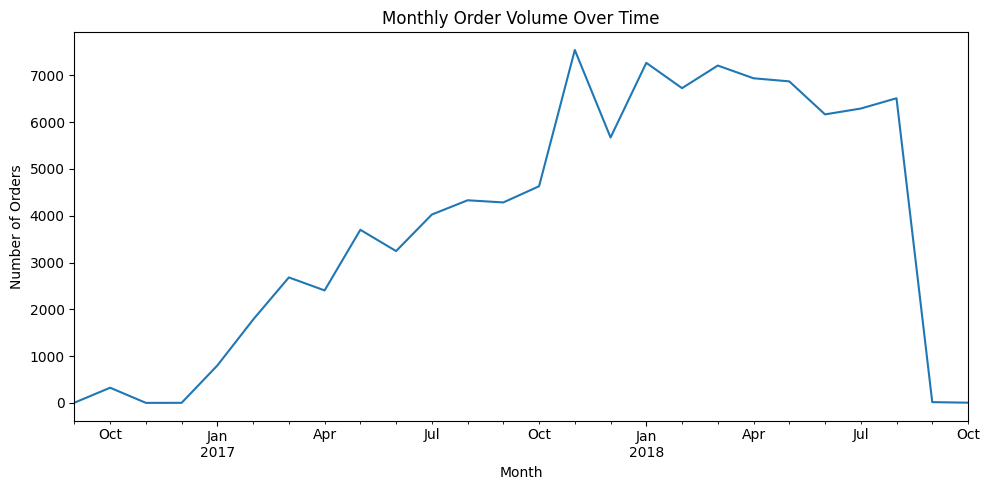

In [36]:
# visualization 1: order volume over time

orders_over_time = (
    orders_full
    .drop_duplicates(subset=["order_id"])
    .set_index("order_purchase_timestamp")
    .resample("M")["order_id"]
    .count()
)

plt.figure(figsize=(10,5))
orders_over_time.plot()
plt.title("Monthly Order Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

The order volume increases steadily over time, with a sharp drop off around September 2018. There doesn't appear to be seasonal patterns, as it looks moreso like a general steady increase rather than month to month flucuation.

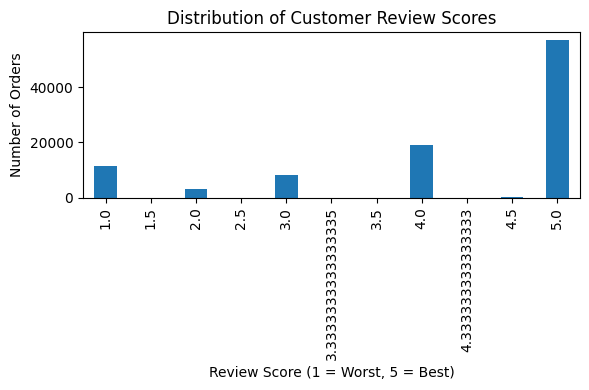

In [37]:
# visualization 2: distribution of review scores

review_dist = (
    orders_full
    .drop_duplicates(subset=["order_id"])
    ["review_score"]
)

plt.figure(figsize=(6,4))
review_dist.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score (1 = Worst, 5 = Best)")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

Most reviews are pretty positive, with 4s and 5s dominating the distribution. This suggests generally strong customer satisfaction.

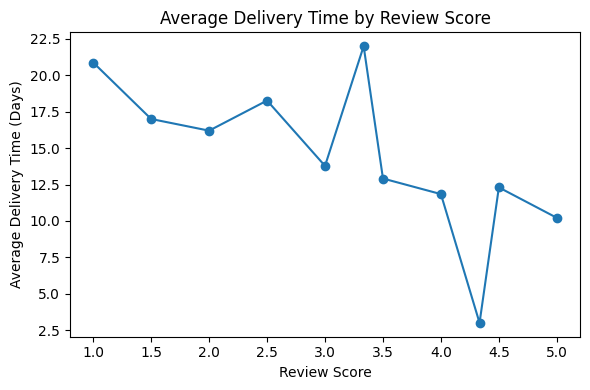

In [38]:
# visualization #3: review score vs delivery performance

delivery_vs_review = (
    orders_full
    .drop_duplicates(subset=["order_id"])
    .groupby("review_score")["delivery_days"]
    .mean()
)

plt.figure(figsize=(6,4))
delivery_vs_review.plot(marker="o")
plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")
plt.tight_layout()
plt.show()

Orders with lower reviews tend to have longer average delivery times, while higher rated orders are delivered faster. This is to be expected, the longer people wait the more annoyed they will be. This clearly indicates delivery speed is a key factor to customer satisfaction.

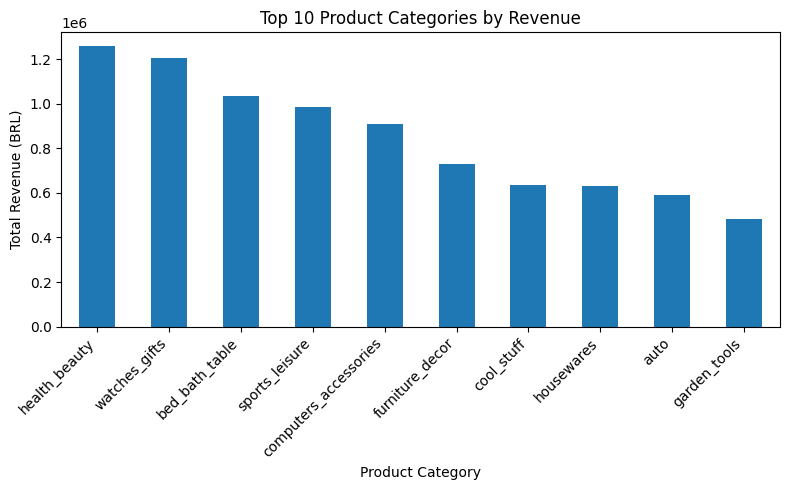

In [39]:
# visualization #4: revenue by product category

revenue_by_category = (
    orders_full
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
revenue_by_category.plot(kind="bar")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The most revenue is generated by beauty/health products, watches, and bed/bath followed closely by sports leisure and computer accessories. These categories should be focused on in marketing and other strategies.

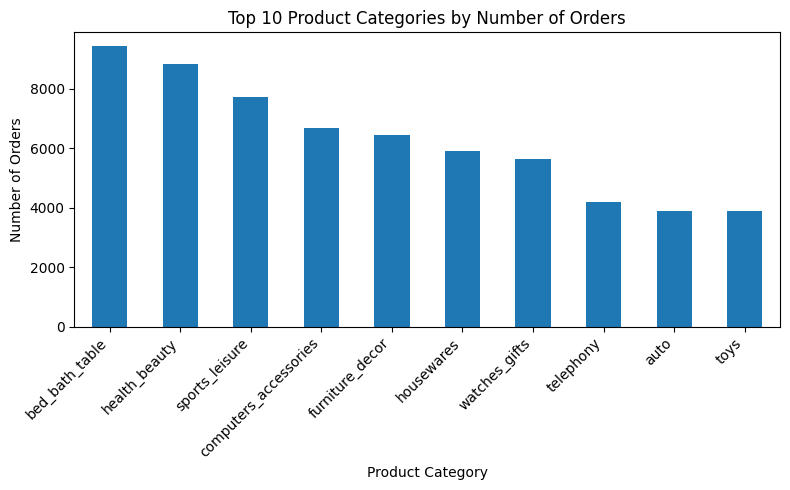

In [40]:
# visualization #5: top product categories by amount of orders

orders_by_category = (
    orders_full
    .drop_duplicates(subset=["order_id", "product_category_name_english"])
    .groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
orders_by_category.plot(kind="bar")
plt.title("Top 10 Product Categories by Number of Orders")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

We see a clear relation to the previous graph as similar categories appear here too. Watches fall down a little, likely due to their expensive nature indicating they are more expensive so do not need to be bought as often to keep up. Order volume is extremely concentrated, showing that customer demand is driven more by everyday items compared to high valued ones.

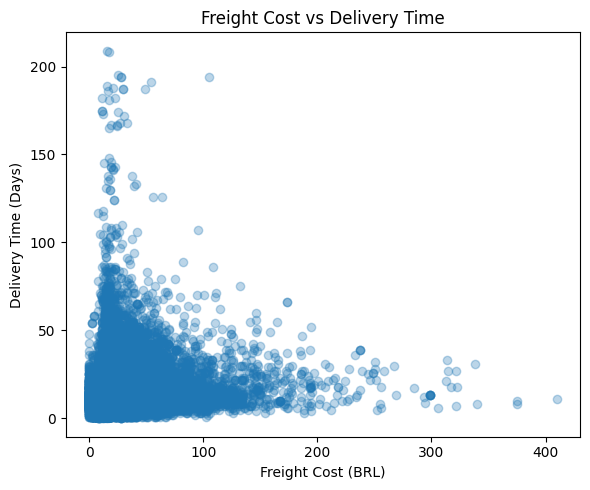

In [41]:
# visualization #6: freight cost vs delivery time

plt.figure(figsize=(6,5))
plt.scatter(
    orders_full["freight_value"],
    orders_full["delivery_days"],
    alpha=0.3
)
plt.title("Freight Cost vs Delivery Time")
plt.xlabel("Freight Cost (BRL)")
plt.ylabel("Delivery Time (Days)")
plt.tight_layout()
plt.show()

There seems to be a small relationship between increasing freight cost and faster delivery time. Most of the longer-awaited orders are on the cheaper side, possibly indicating a non sense of urgency. We see the super expensive ones on the far right have quick delivery times, where as the cheaper costs take the longest.

# Part 6: Executive Summary

This analysis looks at various types of logistics data from the Olist Brazilian marketplace to uncover and better understand business dynamics, performance and customer experience ratings. The market shows clear growth over time, showing increasing adoption and healthy marketplace acticvity. Demand is focused in a strong top few categories, both expensive and commonly purchased items. Higher revenue categories tend to have higher priced, lower frequency purchases, while high order volume categories consist of lower priced, more often purchased items that power engagement.

Customer satisfaction is strong, with review scores more commonly found as 4s and 5s. However, delivery peroformance plays an important role in shaping the customers views and feelings. Longer delivery times and late deliveries are associated with poorer review scores. This indicates fullfillment reliability is a major factor of customer satisfaction. Improving on delivery times would drastically reduce the amount of 1 through 3 rated review scores.

Several data quality considerations were identified but reflect characteristics instead of errors. For example, missing delivery timestamps commonly correspond to real business events such as canceled orders or undelivered orders. Missing review text often represents the choice of the customer to input a review (or not). The geolocation data needed to be aggregated because of repeated entries and the lack of a natural primary key.

The findings pinpoint several opportunities for improvement and even more growth. Focusing on enhancing delivery speed and reliability in slower regions would meaningfully improve customer satisfaction. Higher frequency product categories present opportunities for targeted promotions, increased efforts and focused retention strategies while high revenue categories will benefit from focused seller support. Overall, the marketplace is performing well and the leading categories should continue to be focused on case by case. As for the trailing categories, targeted promotions and loyalty programs would help bring them up.

# AI useage

I used generative AI to help code and improve existing code blocks throughout the assignment. If it generated code and I didn't understand a part of it I would have it explain each line in depth. I went back after I was finished and added some comments explaining the parts of code in my own words for better understanding and to come back to it in the future with confidence.

# ***HOMEWORK 2:***


# Part 1: Data Preparation

In [42]:
# 1 = positive review (4 or 5)
# 0 = negative review (1, 2, or 3)

orders_full["is_positive_review"] = (
    orders_full["review_score"] >= 4
).astype(int)

# quick verification
orders_full[["review_score", "is_positive_review"]].head()

# check distribution
orders_full["is_positive_review"].value_counts()

,count
is_positive_review,
1,84419
0,29006


In [43]:
orders_full.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'review_score', 'review_creation_date', 'review_answer_timestamp',
       'delivery_days', 'delivery_vs_estimated', 'order_hour',
       'order_dayofweek', 'is_positive_review'],
      dtype='object')

Aggregated to order level so modeling doesn't have repeats due to multiple lines per order before this:

In [44]:
# keep only rows with a known target
hw2_df = orders_full.dropna(subset=["is_positive_review"]).copy()

# aggregate from item level to order level
order_level = hw2_df.groupby("order_id").agg(
    # target (should be consistent within an order); take max just to be safe
    is_positive_review=("is_positive_review", "max"),

    # delivery features
    delivery_days=("delivery_days", "max"),
    delivery_vs_estimated=("delivery_vs_estimated", "max"),

    # timing features
    order_hour=("order_hour", "max"),
    order_dayofweek=("order_dayofweek", "max"),

    # geography
    customer_state=("customer_state", "first"),

    # monetary totals (sum across items)
    total_item_price=("price", "sum"),
    total_freight_value=("freight_value", "sum"),

    # complexity features
    num_items=("order_item_id", "count"),
    num_sellers=("seller_id", "nunique"),

    # categorical choices: take the most frequent within the order
    main_product_category=("product_category_name_english", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
    main_seller_state=("seller_state", lambda x: x.mode().iloc[0] if len(x.mode()) else x.iloc[0]),
).reset_index()

order_level.head(), order_level.shape

(                           order_id  is_positive_review  delivery_days  \
 0  00010242fe8c5a6d1ba2dd792cb16214                   1            7.0   
 1  00018f77f2f0320c557190d7a144bdd3                   1           16.0   
 2  000229ec398224ef6ca0657da4fc703e                   1            7.0   
 3  00024acbcdf0a6daa1e931b038114c75                   1            6.0   
 4  00042b26cf59d7ce69dfabb4e55b4fd9                   1           25.0   
 
    delivery_vs_estimated  order_hour  order_dayofweek customer_state  \
 0                   -9.0           8                2             RJ   
 1                   -3.0          10                2             SP   
 2                  -14.0          14                6             MG   
 3                   -6.0          10                2             SP   
 4                  -16.0          13                5             SP   
 
    total_item_price  total_freight_value  num_items  num_sellers  \
 0             58.90                13.

Engineering 4 new features: total order value, freight ratio, a late delivery flagger and order complexity score

In [45]:
# captures total money spent on order, expectations increase with more money spent
order_level["total_order_value"] = (
    order_level["total_item_price"] + order_level["total_freight_value"]
)

# captures how large shipping cost is relative to total cost, no one likes paying a lot for shipping
order_level["freight_ratio"] = (
    order_level["total_freight_value"] /
    order_level["total_order_value"].replace(0, np.nan)
)

# if delivery was late or not
order_level["is_late"] = (
    order_level["delivery_vs_estimated"] > 0
).astype(int)

# captures how complex the fulfillment process is, harder orders to fulfill have higher dissatisfaction chances or more room for error
order_level["order_complexity"] = (
    order_level["num_items"] * order_level["num_sellers"]
)

Feature set

In [46]:
feature_cols = [
    # numeric
    "delivery_days",
    "delivery_vs_estimated",
    "order_hour",
    "order_dayofweek",
    "total_item_price",
    "total_freight_value",
    "total_order_value",
    "freight_ratio",
    "num_items",
    "num_sellers",
    "order_complexity",
    "is_late",

    # categorical
    "main_product_category",
    "main_seller_state",
    "customer_state"
]

X = order_level[feature_cols].copy()
y = order_level["is_positive_review"].astype(int).copy()

X.shape, y.shape

((99441, 15), (99441,))

Encoding categorical variables

In [47]:
# using one hot encoding to create binary columns instead of assigning numbers because categories or states have no order
X_encoded = pd.get_dummies(
    X,
    columns=["main_product_category", "main_seller_state", "customer_state"],
    drop_first=True
)

In [48]:
X_encoded.shape

(99441, 131)

Verifying no missing values in numeric columns

In [49]:
X_encoded.isna().sum().sort_values(ascending=False).head(15)

# 3 features have missing values still

,0
delivery_days,2965
delivery_vs_estimated,2965
freight_ratio,775
order_hour,0
order_dayofweek,0
total_freight_value,0
total_item_price,0
total_order_value,0
num_items,0
num_sellers,0


In [50]:
# imputing missing numeric values using median

numeric_cols = [
    "delivery_days",
    "delivery_vs_estimated",
    "freight_ratio"
]

for col in numeric_cols:
    median_value = X_encoded[col].median()
    X_encoded[col] = X_encoded[col].fillna(median_value)

# Verify
print("Remaining missing values:")
print(X_encoded[numeric_cols].isna().sum())

Remaining missing values:
delivery_days            0
delivery_vs_estimated    0
freight_ratio            0
dtype: int64


I used median imputation for a few reasons: it's more stable than the mean, and it is strong against outliers. The median maintains central tendency without being influenced by extremes. While I could have dropped roughly 3,000 rows, I prefer to avoid removing data where possible.

Train/Test split

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
# train 80%, test 20%

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,      # 20% test
    random_state=42,    # reproducibility
    stratify=y          # preserve class distribution
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTrain positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Training set shape: (79552, 131)
Test set shape: (19889, 131)

Train positive rate: 0.7645565164923572
Test positive rate: 0.7645432148423752


Pipeline setup (Column transformer + pipeline). Keeps columns in original form and lets the transformer do encoding and scaling

In [53]:
# features
numeric_features = [
    "delivery_days",
    "delivery_vs_estimated",
    "order_hour",
    "order_dayofweek",
    "total_item_price",
    "total_freight_value",
    "total_order_value",   # engineered
    "freight_ratio",       # engineered
    "num_items",
    "num_sellers",
    "order_complexity",    # engineered
    "is_late"              # engineered
]

categorical_features = [
    "main_product_category",
    "main_seller_state",
    "customer_state"
]

target = "is_positive_review"

X = order_level[numeric_features + categorical_features].copy()
y = order_level[target].astype(int).copy()

X.shape, y.shape

((99441, 15), (99441,))

Train/test split again (now split the raw X that is NOT encoded yet)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTrain positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

Training set shape: (79552, 15)
Test set shape: (19889, 15)

Train positive rate: 0.7645565164923572
Test positive rate: 0.7645432148423752


Build preprocessing with column transformer

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Part 2: Baseline Model

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# build full pipeline
log_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# fit model
log_pipeline.fit(X_train, y_train)

# predictions
y_pred = log_pipeline.predict(X_test)
y_pred_proba = log_pipeline.predict_proba(X_test)[:, 1]

# metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# print results
print("Baseline Logistic Regression Performance:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline Logistic Regression Performance:
Accuracy:  0.8019
Precision: 0.8072
Recall:    0.9733
F1 Score:  0.8825
ROC-AUC:   0.6921

Confusion Matrix:
[[ 1149  3534]
 [  406 14800]]


The two most important metrics for this case are recall for the negatives specifically and the ROC-AUC. We have 1149 true negatives and 3534 false positives. 1149 / 4683 = 24.5% for negative recall, meaning my model misses 75% of unhappy customers and wrongfully assumes those people left positive reviews. The ROC-AUC of .69 is also important as it shows how good the model is at identifying good vs bad reviews in its current state. .69 is not good, but it's not randomly guessing and has room for improvement.

# Part 3: Model Comparison

Set up scoring and cross validation

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# metrics to compute in cross_validate
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

def cv_report(pipeline, X, y, model_name="model"):

    # runs 5-fold stratified CV and returns a tidy table of mean/std for each metric.

    cv_results = cross_validate(
        pipeline,
        X, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    rows = []
    for metric in scoring.keys():
        vals = cv_results[f"test_{metric}"]
        rows.append({
            "model": model_name,
            "metric": metric,
            "mean": np.mean(vals),
            "std": np.std(vals)
        })
    return pd.DataFrame(rows)

Random Forest:

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# fit on training split
rf_pipeline.fit(X_train, y_train)

# evaluate on held-out test split
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest (Default) — Test Set")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))

Random Forest (Default) — Test Set
Accuracy:  0.8128
Precision: 0.8204
Recall:    0.9667
F1 Score:  0.8876
ROC-AUC:   0.7159

Confusion Matrix:
 [[ 1466  3217]
 [  507 14699]]


^ Took about 2-3 minutes to run

In [59]:
# random Forest — 5-Fold Stratified CV

rf_cv_summary = cv_report(rf_pipeline, X, y, model_name="Random Forest (default)")
rf_cv_summary

,model,metric,mean,std
0,Random Forest (default),accuracy,0.812693,0.002009
1,Random Forest (default),precision,0.820545,0.000924
2,Random Forest (default),recall,0.966354,0.001769
3,Random Forest (default),f1,0.887501,0.001251
4,Random Forest (default),roc_auc,0.719602,0.004760


^ Took much longer, 12 minutes

XGBoost:

In [60]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
        # leave everything else default for the baseline
    ))
])

# fit on training split
xgb_pipeline.fit(X_train, y_train)

# evaluate on held-out test split
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost (Default) — Test Set ===")
print(f"Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb_proba):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred))

=== XGBoost (Default) — Test Set ===
Accuracy:  0.8185
Precision: 0.8257
Recall:    0.9667
F1 Score:  0.8907
ROC-AUC:   0.7282

Confusion Matrix:
 [[ 1581  3102]
 [  507 14699]]


^ Took about 3 seconds

In [61]:
# XGBoost — 5-Fold Stratified CV

xgb_cv_summary = cv_report(xgb_pipeline, X, y, model_name="XGBoost (default)")
xgb_cv_summary

,model,metric,mean,std
0,XGBoost (default),accuracy,0.818475,0.001718
1,XGBoost (default),precision,0.826165,0.000971
2,XGBoost (default),recall,0.965789,0.001837
3,XGBoost (default),f1,0.890536,0.001082
4,XGBoost (default),roc_auc,0.731710,0.005225


^ Took 9 seconds

Log Reg:

In [62]:
# logistic regression — 5-Fold Stratified CV

log_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_cv_summary = cv_report(log_pipeline, X, y, model_name="Logistic Regression (default)")

log_cv_summary

,model,metric,mean,std
0,Logistic Regression (default),accuracy,0.802908,0.002233
1,Logistic Regression (default),precision,0.808244,0.001182
2,Logistic Regression (default),recall,0.973076,0.001818
3,Logistic Regression (default),f1,0.883033,0.001349
4,Logistic Regression (default),roc_auc,0.698555,0.006064


In [63]:
# combine All CV Results

cv_results_all = pd.concat(
    [log_cv_summary, rf_cv_summary, xgb_cv_summary],
    ignore_index=True
)

cv_results_all

,model,metric,mean,std
0,Logistic Regression (default),accuracy,0.802908,0.002233
1,Logistic Regression (default),precision,0.808244,0.001182
2,Logistic Regression (default),recall,0.973076,0.001818
3,Logistic Regression (default),f1,0.883033,0.001349
4,Logistic Regression (default),roc_auc,0.698555,0.006064
5,Random Forest (default),accuracy,0.812693,0.002009
6,Random Forest (default),precision,0.820545,0.000924
7,Random Forest (default),recall,0.966354,0.001769
8,Random Forest (default),f1,0.887501,0.001251
9,Random Forest (default),roc_auc,0.719602,0.004760


In [64]:
# final summary table — cross validation means

summary_table = (
    cv_results_all
    .pivot(index="metric", columns="model", values="mean")
    .round(4)
)

summary_table

model,Logistic Regression (default),Random Forest (default),XGBoost (default)
metric,,,
accuracy,0.8029,0.8127,0.8185
f1,0.8830,0.8875,0.8905
precision,0.8082,0.8205,0.8262
recall,0.9731,0.9664,0.9658
roc_auc,0.6986,0.7196,0.7317


The best model of the three is XGBoost as it leads in accuracy, f1, precision and ROC-AUC.

Class imbalance comparison:

In [65]:
# compute imbalance ratio

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

print("Negative count:", neg)
print("Positive count:", pos)
print("scale_pos_weight:", scale_pos_weight)

Negative count: 18730
Positive count: 60822
scale_pos_weight: 0.3079477820525468


In [66]:
# balanced version

xgb_balanced_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight
    ))
])

# fit
xgb_balanced_pipeline.fit(X_train, y_train)

# predictions
xgb_bal_pred = xgb_balanced_pipeline.predict(X_test)
xgb_bal_proba = xgb_balanced_pipeline.predict_proba(X_test)[:, 1]

print("=== XGBoost (Balanced) Confusion Matrix ===")
print(confusion_matrix(y_test, xgb_bal_pred))

=== XGBoost (Balanced) Confusion Matrix ===
[[ 2397  2286]
 [ 2496 12710]]


Side by side:

In [67]:
print("=== XGBoost (Default) ===")
print(confusion_matrix(y_test, xgb_pred))

print("\n=== XGBoost (Balanced) ===")
print(confusion_matrix(y_test, xgb_bal_pred))

=== XGBoost (Default) ===
[[ 1581  3102]
 [  507 14699]]

=== XGBoost (Balanced) ===
[[ 2397  2286]
 [ 2496 12710]]


Balancing changes the precision/recall tradeoff significantly. The default has low detection of unhappy customers and is more conservative about predicting negatives, while the balanced model is more aggresive about predicting negatives and will lead to less operational losses overall. In simpler terms, the default model can be thought of as something like everyone looks to be happy unless it is super obviously not, while the balanced model is better safe than sorry and may misclassify some happy customers as negatives.

The balanced XGBoost model is better and more appropriate because it improves negative recall from about 33% to 51%, identifying far more unsatisfied customers. The cost of missing an unhappy customer is a lower review, possible brand damage whereas a false positive would result in say an accidental email to the customer. The negative review will hurt much more than an extra email being sent out.

# Part 4: Hyperparameter Tuning

In [68]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 5-fold stratified CV

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# base pipeline

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_base)
])

# parameter grid:

param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.05, 0.1, 0.2],
}

# scoring metric/gridsearch cv: ROC-AUC is robust under imbalance and best at overall reporting how the model did across all possible thresholds

grid = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    verbose=1
)

# fit grid on TRAIN ONLY (prevents test leakage)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV ROC-AUC: 0.7378158384238332


Default vs tuned test set eval:

In [69]:
# default model

xgb_default_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBClassifier(random_state=42, eval_metric="logloss"))
])

xgb_default_pipe.fit(X_train, y_train)

# tuned model

xgb_tuned_pipe = grid.best_estimator_

def eval_model(pipe, X_test, y_test, label="Model"):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    print(f"\n=== {label} — Test Set ===")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    return metrics

default_metrics = eval_model(xgb_default_pipe, X_test, y_test, "XGBoost (Default)")
tuned_metrics = eval_model(xgb_tuned_pipe, X_test, y_test, "XGBoost (Tuned)")

# side-by-side confusion matrices

print("\n--- Confusion Matrices Side-by-Side ---")
print("Default:\n", default_metrics["confusion_matrix"])
print("Tuned:\n", tuned_metrics["confusion_matrix"])


=== XGBoost (Default) — Test Set ===
Accuracy:  0.8185
Precision: 0.8257
Recall:    0.9667
F1 Score:  0.8907
ROC-AUC:   0.7282
Confusion Matrix:
 [[ 1581  3102]
 [  507 14699]]

=== XGBoost (Tuned) — Test Set ===
Accuracy:  0.8206
Precision: 0.8256
Recall:    0.9704
F1 Score:  0.8921
ROC-AUC:   0.7326
Confusion Matrix:
 [[ 1565  3118]
 [  450 14756]]

--- Confusion Matrices Side-by-Side ---
Default:
 [[ 1581  3102]
 [  507 14699]]
Tuned:
 [[ 1565  3118]
 [  450 14756]]


# Part 5: Model Evaluation

In [70]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)

final_model = xgb_tuned_pipe

# predicted probabilities for the positive class (4–5 stars)

y_proba = final_model.predict_proba(X_test)[:, 1]

# default threshold predictions (0.5)

y_pred_05 = (y_proba >= 0.5).astype(int)

=== Confusion Matrix (threshold=0.5) ===
[[ 1565  3118]
 [  450 14756]]

Breakdown:
TN (actual 0, predicted 0): 1565
FP (actual 0, predicted 1): 3118  <- predicted POSITIVE but actually NEGATIVE (missed unhappy customer)
FN (actual 1, predicted 0): 450  <- predicted NEGATIVE but actually POSITIVE (unnecessary intervention)
TP (actual 1, predicted 1): 14756

Rates (by actual class):
Negative recall (TN / (TN+FP)): 0.3342  <- how many unhappy customers we correctly flag as negative
Positive recall (TP / (TP+FN)): 0.9704


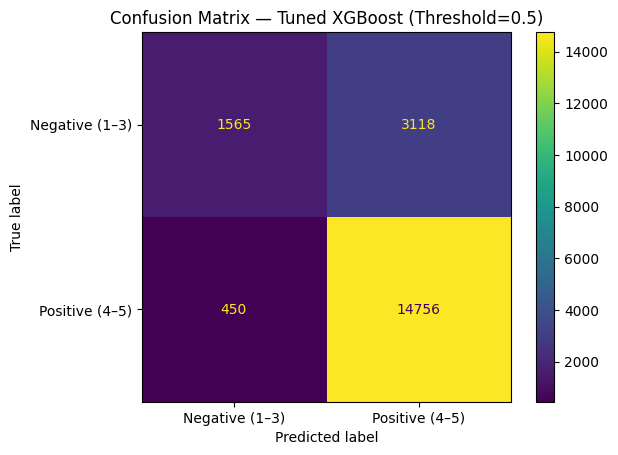

In [71]:
# confusion matrix (threshold = 0.5)

cm = confusion_matrix(y_test, y_pred_05)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix (threshold=0.5) ===")
print(cm)

print("\nBreakdown:")
print(f"TN (actual 0, predicted 0): {tn}")
print(f"FP (actual 0, predicted 1): {fp}  <- predicted POSITIVE but actually NEGATIVE (missed unhappy customer)")
print(f"FN (actual 1, predicted 0): {fn}  <- predicted NEGATIVE but actually POSITIVE (unnecessary intervention)")
print(f"TP (actual 1, predicted 1): {tp}")

# useful rates

neg_total = tn + fp
pos_total = fn + tp
print("\nRates (by actual class):")
print(f"Negative recall (TN / (TN+FP)): {tn/neg_total:.4f}  <- how many unhappy customers we correctly flag as negative")
print(f"Positive recall (TP / (TP+FN)): {tp/pos_total:.4f}")

# plot

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative (1–3)", "Positive (4–5)"])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Tuned XGBoost (Threshold=0.5)")
plt.show()

The model is making errors on FP (missed unhappy customer) and FN (predicted neg but is pos, no action needed)

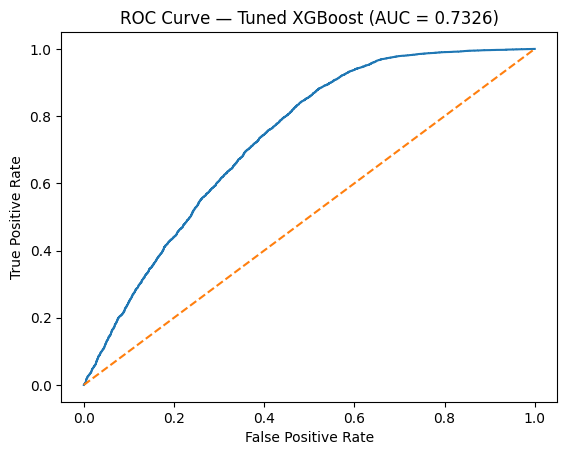

ROC-AUC: 0.7326


In [72]:
#ROC Curve + AUC

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — Tuned XGBoost (AUC = {auc:.4f})")
plt.show()

print(f"ROC-AUC: {auc:.4f}")

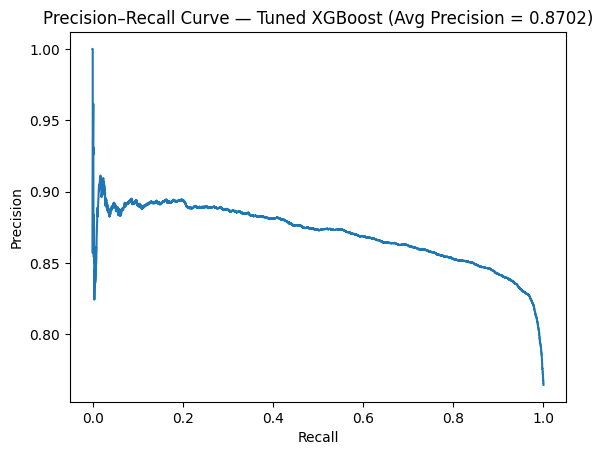

Average Precision (AP): 0.8702


In [73]:
# precision-recall curve + avg precision

prec, rec, _ = precision_recall_curve(y_test, y_proba)
avg_prec = average_precision_score(y_test, y_proba)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve — Tuned XGBoost (Avg Precision = {avg_prec:.4f})")
plt.show()

print(f"Average Precision (AP): {avg_prec:.4f}")

In [74]:
# threshold analysis (positive class = 4–5 stars)
thresholds = np.linspace(0.05, 0.95, 19)

rows = []
for thr in thresholds:
    pred_thr = (y_proba >= thr).astype(int)
    rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr, zero_division=0),
        "recall": recall_score(y_test, pred_thr, zero_division=0),
        "f1": f1_score(y_test, pred_thr, zero_division=0)
    })

thr_table = pd.DataFrame(rows)

# show table
thr_table

,threshold,accuracy,precision,recall,f1
0,0.05,0.765147,0.765031,0.999934,0.866851
1,0.10,0.777163,0.775156,0.998027,0.872585
2,0.15,0.792951,0.789262,0.994805,0.880193
3,0.20,0.797677,0.794356,0.992240,0.882339
4,0.25,0.803811,0.800255,0.990662,0.885336
5,0.30,0.811554,0.809241,0.985927,0.888889
6,0.35,0.816230,0.815964,0.980863,0.890847
7,0.40,0.819297,0.820137,0.978167,0.892208
8,0.45,0.820102,0.823036,0.974155,0.892242
9,0.50,0.820604,0.825557,0.970406,0.892140


Yes, there is a better threshold (range) that balances the business tradeoff. The goal here is to find the threshold that improves negative recall without booming false positives. This happens between .35 to .45 threshold. This range will identify more dissatisfied customers, while lower and higher than this range tend to have stronger effects in other metrics.

# Part 6: Model Interpretation with SHAP

Extract fitted preprocessor and fitted XGBoost model from previous pipeline

In [75]:
# use your tuned pipeline
final_pipe = xgb_tuned_pipe

# pull out fitted components
pre = final_pipe.named_steps["preprocess"]
xgb_model = final_pipe.named_steps["model"]

type(pre), type(xgb_model)

(sklearn.compose._column_transformer.ColumnTransformer,
 xgboost.sklearn.XGBClassifier)

In [76]:
# transform data exactly how the model sees it
X_test_trans = pre.transform(X_test)

# helper to get feature names out of ColumnTransformer
def get_ct_feature_names(column_transformer):
    feature_names = []

    for name, transformer, cols in column_transformer.transformers_:
        if name == "remainder":
            continue

        # pipeline case
        if hasattr(transformer, "named_steps"):
            last_step = list(transformer.named_steps.values())[-1]
        else:
            last_step = transformer

        # OneHotEncoder: expand names
        if hasattr(last_step, "get_feature_names_out"):
            try:
                names = last_step.get_feature_names_out(cols)
            except TypeError:
                names = last_step.get_feature_names_out()
            feature_names.extend(names)
        else:
            # numeric passthrough/scaler: keep original column names
            if isinstance(cols, (list, tuple, np.ndarray, pd.Index)):
                feature_names.extend([str(c) for c in cols])
            else:
                feature_names.append(str(cols))

    return feature_names

feature_names = get_ct_feature_names(pre)

# convert transformed matrix to DataFrame for SHAP (helps readability)
X_test_trans_df = pd.DataFrame(
    X_test_trans.toarray() if hasattr(X_test_trans, "toarray") else X_test_trans,
    columns=feature_names
)

X_test_trans_df.shape

(19889, 134)

Plot features are ordered by overall impact

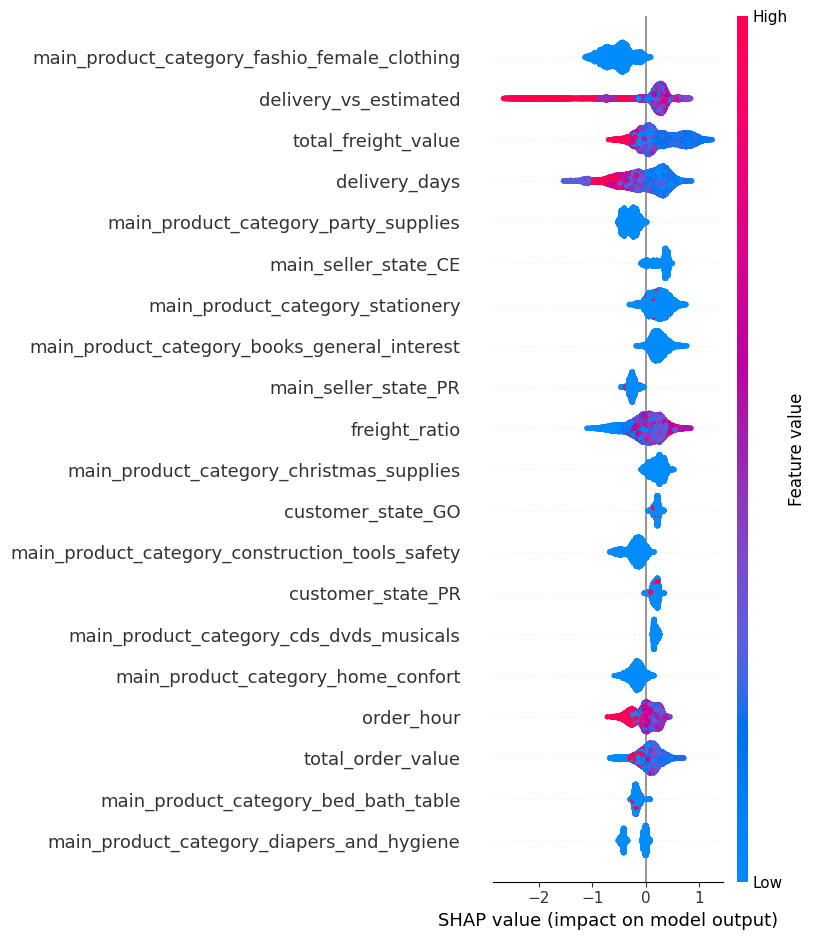

In [77]:
explainer = shap.TreeExplainer(xgb_model)

# compute SHAP values for the transformed test data
shap_values = explainer.shap_values(X_test_trans_df)

# SHAP summary plot (feature importance + direction of impact)
shap.summary_plot(shap_values, X_test_trans_df, show=True)

Right side (positive side) pushes prediction towards a positive review, while left side (negative side) pushes prediction toward negative review.

In [78]:
if isinstance(shap_values, list):
    shap_array = shap_values[1]  # positive class (4–5 stars)
else:
    shap_array = shap_values

# mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# create ranked table
shap_importance = (
    pd.DataFrame({
        "feature": X_test_trans_df.columns,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# display top 5
top5 = shap_importance.head(5)
top5

,feature,mean_abs_shap
0,main_product_category_fashio_female_clothing,0.523341
1,delivery_vs_estimated,0.356767
2,total_freight_value,0.341161
3,delivery_days,0.338575
4,main_product_category_party_supplies,0.281475


Top 3 features:

Orders in the **Female Fashion Category** significantly influence review outcomes because customers are naturally more critical in this category, or any fashion category for that matter. Clothing purchases often come with high or exact expectations that when aren't met can be frustrating leading to poor reviews.

When **delivery_vs_estimated** is late (positive values) the model will lean toward a negative review, where if it is early (negative value) it will push more toward a positive review.

Shipping costs have strong impact on customer dissatisfaction so when **total_freight_value** is high, the likelihood for a negative review goes up.

In [79]:
# get predictions at default threshold 0.5
y_pred = (y_proba >= 0.5).astype(int)

# identify indices
correct_negative_idx = np.where((y_test == 0) & (y_pred == 0))[0][0]
correct_positive_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

correct_negative_idx, correct_positive_idx

(np.int64(15), np.int64(0))

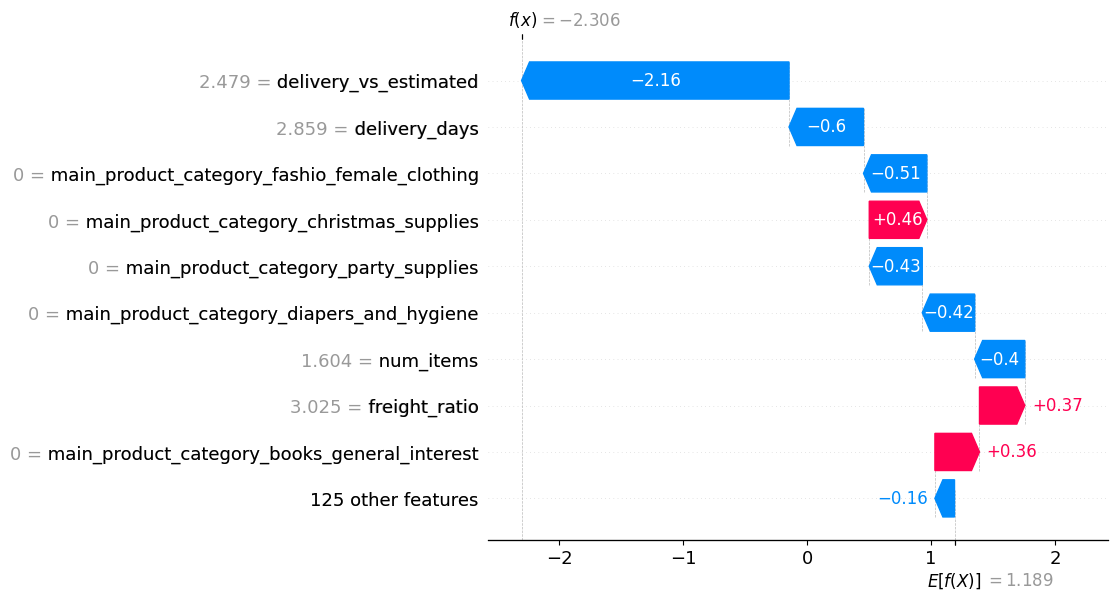

In [80]:
# SHAP values for that individual instance
neg_shap = shap_array[correct_negative_idx]

# create explanation object
neg_explanation = shap.Explanation(
    values=neg_shap,
    base_values=explainer.expected_value,
    data=X_test_trans_df.iloc[correct_negative_idx],
    feature_names=X_test_trans_df.columns
)

shap.plots.waterfall(neg_explanation, max_display=10)

For the correctly classified negative review, the model was primarily driven by a positive delivery_vs_estimated delay indicating that poor review was likely caused by the delay.

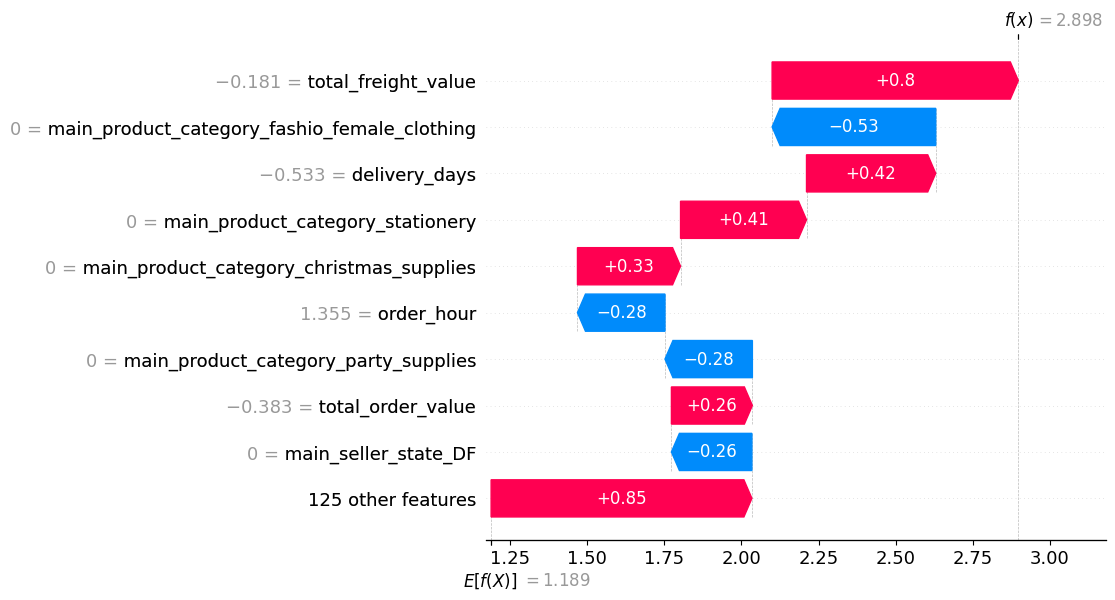

In [81]:
pos_shap = shap_array[correct_positive_idx]

pos_explanation = shap.Explanation(
    values=pos_shap,
    base_values=explainer.expected_value,
    data=X_test_trans_df.iloc[correct_positive_idx],
    feature_names=X_test_trans_df.columns
)

shap.plots.waterfall(pos_explanation, max_display=10)

As for the correctly classified positive review, the model was heavily influenced by reasonable freight costs and the absence of delay. A combination of spending less and getting the product earlier will often lead to a better review.

# Part 7: Business Recommendations

My final tuned XGBoost model demonstrates meaningful predictive power with a ROC-AUC of 0.73 and accuracy of 81%. The model identifies over half of dissatisfied customers (51%) compared to about one third under original settings. While it's not perfect, it represents a large improvement in detecting at risk orders. The model is not ready yet for full deployment, 51% is actionable but can be improved upon.

SHAP analysis pinpointed two primary forces that lead to negative reviews: delivery performance and product category sensitivity. More specifically, delivery delays past the estimated date, longer delivery times in general and higher freight costs significantly increase the risk of a negative review. Also, certain categories like female fashion and party supplies carry elevated risk. This is because those categories bring higher or exact expectations and time sensitivity. Olist can control delivery accuracy, shipping prices, and carrier performance.

I recommend two immediate actions:
1. Prioritize on time deliveries, especially for high risk categories. Create proactive alerts and quick communication with customers when delays do happen.
2. Review freight pricing. Look in depth where shipping represents a large share of the total order cost. There should be transparency with costs especially in sensitive categories.

Limitations include relying on structured transaction data that does not include how long the customer has been a customer, or past seller performance trends. Also, since the model reflects historical trends and patterns it may shift as business and operations evolve over time. Additional data that would improve the model include customer behavioral data, so things like tenure, repeat buyer or not, return frequency, etc. Seller historical data would also be an improvement because we can see if/where some sellers are underperforming and compare those to the negative reviews. Third, carrier and logistics performance data to isolate between single delivery issues or a larger overall problem.

While improvements have been made, the model is not yet ready for production use. It needs to undergo A/B testing, and ideally obtain the data mentioned previously. The most impactful next step would be to obtain and begin integrating the other data to get deeper insights and push the ROC-AUC higher.

# ***HOMEWORK 3***

# Part 1: Setup and data prep

I will be going with AutoGluon because pycaret has compatability issues in newer python runtimes (python 3.12, colab) where AutoGluon does not. Also, after a little research it seems AutoGluon is the stronger tool in general.

I initially tried to install pycaret and move forward with that, but it brought about a few issues right away that wasted a lot of time. I encountered multiple broken process pool errors, and had to mess with n_jobs from -1 to 1 forcing it to go through them one by one instead of simultaneously. Then, just starting part 2 I tried importing pycaret classifications and that's when I found out pycaret has support issues with newer runtimes, and told me to downgrade my colab python version. Instead of dealing with that, I swapped to AutoGluon.

In [82]:
# confirm target and feature setup
print("Target variable:", "is_positive_review")
print("Number of features:", len(feature_cols))
print("First 10 features:", feature_cols[:10])

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Target variable: is_positive_review
Number of features: 15
First 10 features: ['delivery_days', 'delivery_vs_estimated', 'order_hour', 'order_dayofweek', 'total_item_price', 'total_freight_value', 'total_order_value', 'freight_ratio', 'num_items', 'num_sellers']

Training set shape: (79552, 15)
Test set shape: (19889, 15)

Training target distribution:
is_positive_review
1    0.764557
0    0.235443
Name: proportion, dtype: float64

Test target distribution:
is_positive_review
1    0.764543
0    0.235457
Name: proportion, dtype: float64


In [83]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_classifier(model, X_test, y_test, label="Model"):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return pd.DataFrame([{
        "Model": label,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }])

In [84]:
baseline_results = evaluate_classifier(
    xgb_tuned_pipe,
    X_test,
    y_test,
    label="HW2 Tuned XGBoost"
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,HW2 Tuned XGBoost,0.820604,0.825557,0.970406,0.89214,0.732556


# Part 2: AutoML experiments

In [85]:
import time

In [86]:
# helper function

def evaluate_autogluon(predictor, test_df, label_col="is_positive_review", label_name="AutoML Model"):
    y_true = test_df[label_col]
    X_test_only = test_df.drop(columns=[label_col])

    y_pred = predictor.predict(X_test_only)
    y_proba = predictor.predict_proba(X_test_only)

    # probability of class 1
    if 1 in y_proba.columns:
        pos_proba = y_proba[1]
    else:
        pos_proba = y_proba.iloc[:, 1]

    results = pd.DataFrame([{
        "Model": label_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, pos_proba)
    }])

    return results, y_pred, pos_proba

In [87]:
# preparing constrained train/test data

train_constrained = X_train.copy()
train_constrained["is_positive_review"] = y_train.values

test_constrained = X_test.copy()
test_constrained["is_positive_review"] = y_test.values

print("Train constrained shape:", train_constrained.shape)
print("Test constrained shape:", test_constrained.shape)

Train constrained shape: (79552, 16)
Test constrained shape: (19889, 16)


In [88]:
# running experiment A (constrained one, same feature set from hw2)

start_a = time.time()

predictor_a = TabularPredictor(
    label="is_positive_review",
    eval_metric="roc_auc",
    problem_type="binary"
).fit(
    train_data=train_constrained,
    time_limit=600,   # 10 minutes
    presets="medium_quality"
)

train_time_a = time.time() - start_a

print("Experiment A total training time (seconds):", round(train_time_a, 2))

No path specified. Models will be saved in: "AutogluonModels/ag-20260421_210800"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       8.32 GB / 12.67 GB (65.6%)
Disk Space Avail:   75.21 GB / 107.72 GB (69.8%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/AutogluonModels/ag-20260421_210800"
Train Data Rows:    79552
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting 

Experiment A total training time (seconds): 327.41


In [89]:
# leaderboard for models tried (Experiment A)

leaderboard_a = predictor_a.leaderboard(test_constrained, silent=True)
leaderboard_a

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.734495,0.745511,roc_auc,2.096670,0.304802,45.018241,0.003003,0.000648,0.101755,2,True,12
1,LightGBMLarge,0.733866,0.737170,roc_auc,0.202295,0.027358,2.137115,0.202295,0.027358,2.137115,1,True,11
2,LightGBMXT,0.733161,0.741388,roc_auc,0.647691,0.078576,5.281850,0.647691,0.078576,5.281850,1,True,1
3,LightGBM,0.732783,0.741271,roc_auc,0.127847,0.012644,1.227832,0.127847,0.012644,1.227832,1,True,2
4,CatBoost,0.732121,0.743178,roc_auc,0.082322,0.006307,26.387482,0.082322,0.006307,26.387482,1,True,5
5,XGBoost,0.731735,0.739473,roc_auc,0.054451,0.026767,1.948607,0.054451,0.026767,1.948607,1,True,9
6,NeuralNetFastAI,0.724671,0.733223,roc_auc,0.263523,0.040375,68.739538,0.263523,0.040375,68.739538,1,True,8
7,ExtraTreesEntr,0.720928,0.732444,roc_auc,1.178123,0.219869,12.656174,1.178123,0.219869,12.656174,1,True,7
8,ExtraTreesGini,0.720878,0.736182,roc_auc,1.235807,0.206628,12.019322,1.235807,0.206628,12.019322,1,True,6
9,RandomForestGini,0.720245,0.725029,roc_auc,1.783330,0.389719,39.417879,1.783330,0.389719,39.417879,1,True,3


In [90]:
# best model test performance (Experiment A)

a_results, a_pred, a_proba = evaluate_autogluon(
    predictor_a,
    test_constrained,
    label_col="is_positive_review",
    label_name=f"Experiment A Best: {predictor_a.model_best}"
)

a_results["Training_Time_sec"] = train_time_a
a_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,Experiment A Best: WeightedEnsemble_L2,0.822515,0.826291,0.972248,0.893347,0.734495,327.411814


In [91]:
# experiment B set up (unconstrained)
# broader set of non-leaky features

leakage_cols = [
    "is_positive_review",
    "order_id",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "review_creation_date",
    "review_answer_timestamp"
]

valid_unconstrained_features = [
    c for c in order_level.columns
    if c not in leakage_cols
]

unconstrained_df = order_level[valid_unconstrained_features + ["is_positive_review"]].copy()

train_idx = X_train.index
test_idx = X_test.index

train_unconstrained = unconstrained_df.loc[train_idx].copy()
test_unconstrained = unconstrained_df.loc[test_idx].copy()

print("Train unconstrained shape:", train_unconstrained.shape)
print("Test unconstrained shape:", test_unconstrained.shape)

Train unconstrained shape: (79552, 16)
Test unconstrained shape: (19889, 16)


In [92]:
# running experiment B

start_b = time.time()

predictor_b = TabularPredictor(
    label="is_positive_review",
    eval_metric="roc_auc",
    problem_type="binary"
).fit(
    train_data=train_unconstrained,
    time_limit=1200,   # 20 minutes
    presets="medium_quality"
)

train_time_b = time.time() - start_b

print("Experiment B total training time (seconds):", round(train_time_b, 2))

No path specified. Models will be saved in: "AutogluonModels/ag-20260421_211339"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       8.67 GB / 12.67 GB (68.4%)
Disk Space Avail:   72.66 GB / 107.72 GB (67.5%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/AutogluonModels/ag-20260421_211339"
Train Data Rows:    79552
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting

Experiment B total training time (seconds): 306.81


In [93]:
# leaderboard for models tried (experiment B)

leaderboard_b = predictor_b.leaderboard(test_unconstrained, silent=True)
leaderboard_b

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.735696,0.745501,roc_auc,3.676044,0.327486,146.445775,0.011839,0.000649,0.100075,2,True,12
1,LightGBMLarge,0.733481,0.739463,roc_auc,0.240763,0.028841,2.752229,0.240763,0.028841,2.752229,1,True,11
2,LightGBMXT,0.733008,0.740618,roc_auc,0.325508,0.140360,3.576474,0.325508,0.140360,3.576474,1,True,1
3,LightGBM,0.732783,0.741271,roc_auc,0.087281,0.070290,3.332127,0.087281,0.070290,3.332127,1,True,2
4,CatBoost,0.731928,0.741914,roc_auc,0.118989,0.006318,30.660613,0.118989,0.006318,30.660613,1,True,5
5,XGBoost,0.731735,0.739473,roc_auc,0.072074,0.010073,1.200495,0.072074,0.010073,1.200495,1,True,9
6,NeuralNetFastAI,0.727402,0.738209,roc_auc,0.352759,0.028743,67.213555,0.352759,0.028743,67.213555,1,True,8
7,ExtraTreesGini,0.722470,0.730363,roc_auc,4.112017,0.225642,12.404524,4.112017,0.225642,12.404524,1,True,6
8,RandomForestEntr,0.722433,0.732015,roc_auc,3.033102,0.211413,43.938910,3.033102,0.211413,43.938910,1,True,4
9,ExtraTreesEntr,0.721124,0.728947,roc_auc,3.411522,0.201848,12.664114,3.411522,0.201848,12.664114,1,True,7


In [94]:
# best model test performance (experiment B)

b_results, b_pred, b_proba = evaluate_autogluon(
    predictor_b,
    test_unconstrained,
    label_col="is_positive_review",
    label_name=f"Experiment B Best: {predictor_b.model_best}"
)

b_results["Training_Time_sec"] = train_time_b
b_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Training_Time_sec
0,Experiment B Best: WeightedEnsemble_L2,0.823018,0.825769,0.974023,0.89379,0.735696,306.809623


In [95]:
# feature importance (experiment B)

try:
    feature_importance_b = predictor_b.feature_importance(test_unconstrained)
    print("Top 15 most important features from Experiment B:")
    display(feature_importance_b.head(15))
except Exception as e:
    print("Feature importance could not be generated:", e)

Computing feature importance via permutation shuffling for 15 features using 5000 rows with 5 shuffle sets...
	75.38s	= Expected runtime (15.08s per shuffle set)
	30.76s	= Actual runtime (Completed 5 of 5 shuffle sets)


Top 15 most important features from Experiment B:


,importance,stddev,p_value,n,p99_high,p99_low
delivery_days,0.046410,0.005230,0.000019,5,0.057178,0.035642
delivery_vs_estimated,0.044175,0.003858,0.000007,5,0.052118,0.036232
num_items,0.012149,0.003049,0.000439,5,0.018427,0.005870
main_product_category,0.011179,0.003621,0.001155,5,0.018635,0.003723
order_complexity,0.005357,0.001256,0.000338,5,0.007944,0.002770
main_seller_state,0.003782,0.001355,0.001682,5,0.006572,0.000991
customer_state,0.002798,0.001776,0.012195,5,0.006456,-0.000859
num_sellers,0.002716,0.001309,0.004862,5,0.005410,0.000022
total_freight_value,0.002173,0.001169,0.007102,5,0.004580,-0.000235
is_late,0.001961,0.001090,0.007923,5,0.004205,-0.000284


# Part 3: Rigorous performance comparison

In [96]:
# comparison table

comparison_df = pd.DataFrame([
    {
        "Approach": "HW2 Manual",
        "Best_Model_Type": type(xgb_tuned_pipe.named_steps["model"]).__name__,
        "Training_Time_sec": np.nan,
        "Accuracy": float(baseline_results["Accuracy"].iloc[0]),
        "Precision": float(baseline_results["Precision"].iloc[0]),
        "Recall": float(baseline_results["Recall"].iloc[0]),
        "F1": float(baseline_results["F1"].iloc[0]),
        "ROC_AUC": float(baseline_results["ROC_AUC"].iloc[0])
    },
    {
        "Approach": "AutoML-Constrained",
        "Best_Model_Type": predictor_a.model_best,
        "Training_Time_sec": train_time_a,
        "Accuracy": float(a_results["Accuracy"].iloc[0]),
        "Precision": float(a_results["Precision"].iloc[0]),
        "Recall": float(a_results["Recall"].iloc[0]),
        "F1": float(a_results["F1"].iloc[0]),
        "ROC_AUC": float(a_results["ROC_AUC"].iloc[0])
    },
    {
        "Approach": "AutoML-Unconstrained",
        "Best_Model_Type": predictor_b.model_best,
        "Training_Time_sec": train_time_b,
        "Accuracy": float(b_results["Accuracy"].iloc[0]),
        "Precision": float(b_results["Precision"].iloc[0]),
        "Recall": float(b_results["Recall"].iloc[0]),
        "F1": float(b_results["F1"].iloc[0]),
        "ROC_AUC": float(b_results["ROC_AUC"].iloc[0])
    }
])

comparison_df.sort_values("ROC_AUC", ascending=False)

,Approach,Best_Model_Type,Training_Time_sec,Accuracy,Precision,Recall,F1,ROC_AUC
2,AutoML-Unconstrained,WeightedEnsemble_L2,306.809623,0.823018,0.825769,0.974023,0.893790,0.735696
1,AutoML-Constrained,WeightedEnsemble_L2,327.411814,0.822515,0.826291,0.972248,0.893347,0.734495
0,HW2 Manual,XGBClassifier,NaN,0.820604,0.825557,0.970406,0.892140,0.732556


In [97]:
# extra prep

hw2_pred = xgb_tuned_pipe.predict(X_test)
hw2_proba = xgb_tuned_pipe.predict_proba(X_test)[:, 1]

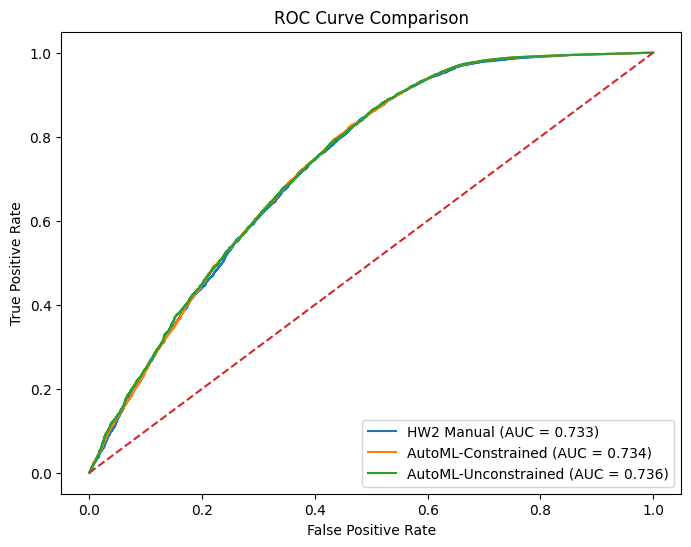

In [98]:
# ROC curve comparison and plot

from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

roc_inputs = [
    ("HW2 Manual", hw2_proba if "hw2_proba" in globals() else xgb_tuned_pipe.predict_proba(X_test)[:, 1]),
    ("AutoML-Constrained", a_proba),
    ("AutoML-Unconstrained", b_proba)
]

for label, probs in roc_inputs:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [99]:
# finding the best AutoML model

best_automl_name = "AutoML-Constrained" if float(a_results["ROC_AUC"].iloc[0]) >= float(b_results["ROC_AUC"].iloc[0]) else "AutoML-Unconstrained"

print("Best AutoML approach:", best_automl_name)

if best_automl_name == "AutoML-Constrained":
    best_predictor = predictor_a
    best_train_df = train_constrained.copy()
    best_test_df = test_constrained.copy()
    best_time_limit = 600   # 10 min
else:
    best_predictor = predictor_b
    best_train_df = train_unconstrained.copy()
    best_test_df = test_unconstrained.copy()
    best_time_limit = 1200  # 20 min

print("Best AutoML model type:", best_predictor.model_best)

Best AutoML approach: AutoML-Unconstrained
Best AutoML model type: WeightedEnsemble_L2


In [100]:
# helpers

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import scipy.stats as stats
import os
import shutil

def ci_95(scores):
    scores = np.array(scores)
    mean = scores.mean()
    std = scores.std(ddof=1)
    n = len(scores)
    margin = stats.t.ppf(0.975, df=n-1) * (std / np.sqrt(n))
    return mean, std, mean - margin, mean + margin

In [101]:
# 5 fold CV for hw2 manual model

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hw2_cv_scores = cross_val_score(
    clone(xgb_tuned_pipe),
    X,
    y,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

hw2_mean, hw2_std, hw2_ci_low, hw2_ci_high = ci_95(hw2_cv_scores)

print("HW2 fold ROC-AUC scores:", hw2_cv_scores)
print("HW2 mean ROC-AUC:", hw2_mean)
print("HW2 std:", hw2_std)
print("HW2 95% CI:", (hw2_ci_low, hw2_ci_high))

HW2 fold ROC-AUC scores: [0.74307455 0.74485577 0.73686431 0.73732128 0.73011839]
HW2 mean ROC-AUC: 0.7384468588970066
HW2 std: 0.005822893588869509
HW2 95% CI: (np.float64(0.7312167815623358), np.float64(0.7456769362316773))


In [102]:
# 5 fold CV for best AutoML model

automl_cv_scores = []

X_best = best_train_df.drop(columns=["is_positive_review"])
y_best = best_train_df["is_positive_review"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_best, y_best), start=1):
    print(f"Running AutoML CV fold {fold}...")

    fold_train = best_train_df.iloc[train_idx].copy()
    fold_val = best_train_df.iloc[val_idx].copy()

    fold_path = f"Autogluon_fold_{fold}"
    if os.path.exists(fold_path):
        shutil.rmtree(fold_path)

    fold_predictor = TabularPredictor(
        label="is_positive_review",
        eval_metric="roc_auc",
        problem_type="binary",
        path=fold_path
    ).fit(
        train_data=fold_train,
        time_limit=best_time_limit,
        presets="medium_quality"
    )

    fold_proba_df = fold_predictor.predict_proba(fold_val.drop(columns=["is_positive_review"]))

    if 1 in fold_proba_df.columns:
        fold_proba = fold_proba_df[1]
    else:
        fold_proba = fold_proba_df.iloc[:, 1]

    fold_auc = roc_auc_score(fold_val["is_positive_review"], fold_proba)
    automl_cv_scores.append(fold_auc)

    print(f"Fold {fold} ROC-AUC: {fold_auc:.4f}")

automl_cv_scores = np.array(automl_cv_scores)

auto_mean, auto_std, auto_ci_low, auto_ci_high = ci_95(automl_cv_scores)

print("\nAutoML fold ROC-AUC scores:", automl_cv_scores)
print("AutoML mean ROC-AUC:", auto_mean)
print("AutoML std:", auto_std)
print("AutoML 95% CI:", (auto_ci_low, auto_ci_high))

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       7.96 GB / 12.67 GB (62.8%)
Disk Space Avail:   70.15 GB / 107.72 GB (65.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'


Running AutoML CV fold 1...


Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/Autogluon_fold_1"
Train Data Rows:    63641
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8136.52 MB
	Train Data (Original)  Memory Usage: 15.25 MB (0.2% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeature

Fold 1 ROC-AUC: 0.7414
Running AutoML CV fold 2...


Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/Autogluon_fold_2"
Train Data Rows:    63641
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8223.29 MB
	Train Data (Original)  Memory Usage: 15.26 MB (0.2% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeature

...

Fold 3 ROC-AUC: 0.7394
Running AutoML CV fold 4...


Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/Autogluon_fold_4"
Train Data Rows:    63642
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8508.13 MB
	Train Data (Original)  Memory Usage: 15.26 MB (0.2% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeature

Fold 4 ROC-AUC: 0.7426
Running AutoML CV fold 5...


Beginning AutoGluon training ... Time limit = 1200s
AutoGluon will save models to "/content/Autogluon_fold_5"
Train Data Rows:    63642
Train Data Columns: 15
Label Column:       is_positive_review
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = 1, class 0 = 0
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    8408.40 MB
	Train Data (Original)  Memory Usage: 15.26 MB (0.2% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTypeFeatureGenerator...
			Note: Converting 1 features to boolean dtype as they only contain 2 unique values.
	Stage 2 Generators:
		Fitting FillNaFeatureGenerator...
	Stage 3 Generators:
		Fitting IdentityFeatureGenerator...
		Fitting CategoryFeatureGenerator...
			Fitting CategoryMemoryMinimizeFeature

Fold 5 ROC-AUC: 0.7406

AutoML fold ROC-AUC scores: [0.74140062 0.73817076 0.73943185 0.74256935 0.74060449]
AutoML mean ROC-AUC: 0.740435414461192
AutoML std: 0.0017065825174365093
AutoML 95% CI: (np.float64(0.7383164123893271), np.float64(0.7425544165330569))


In [103]:
# summary table & paired T test

t_stat, p_value = stats.ttest_rel(hw2_cv_scores, automl_cv_scores)

cv_summary = pd.DataFrame([
    {
        "Model": "HW2 Manual",
        "CV Mean ROC_AUC": hw2_mean,
        "CV Std": hw2_std,
        "95% CI Low": hw2_ci_low,
        "95% CI High": hw2_ci_high
    },
    {
        "Model": best_automl_name,
        "CV Mean ROC_AUC": auto_mean,
        "CV Std": auto_std,
        "95% CI Low": auto_ci_low,
        "95% CI High": auto_ci_high
    }
])

cv_summary
print("Paired t-test p-value:", p_value)

Paired t-test p-value: 0.5347019583477866


Since p = 0.68917 > 0.05, I fail to reject the null hypothesis that both models have the same avg performance. There is not enough edvidence to conclude that the best AutoML model had any meaningful advantage over the hw2 model, in other words it is NOT statistically significant.

This alone should not drive a business decision one way or the other because the difference was not strong enough to conclude that it would consistently outperform the other in production. The final model choice must include other factors like training time and interpretability.

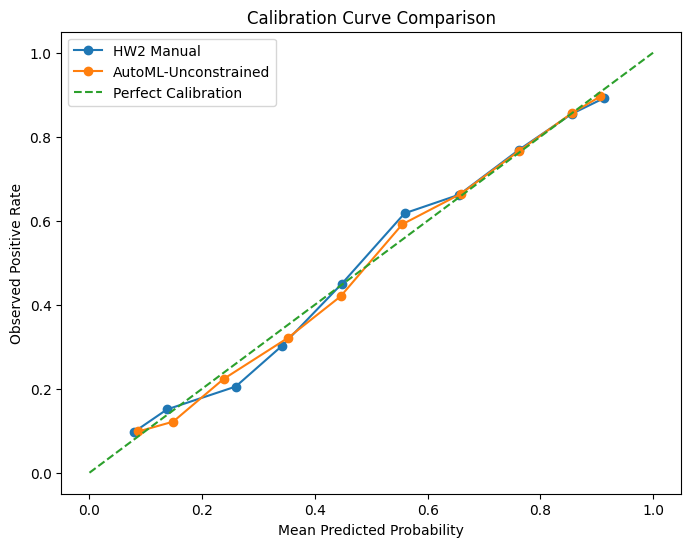

HW2 Brier score: 0.14169814620394924
AutoML-Unconstrained Brier score: 0.14019256485620593


In [104]:
# calibration curve comparison
# comparing hw2 manual model and best AutoML model

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

hw2_probs = hw2_proba if "hw2_proba" in globals() else xgb_tuned_pipe.predict_proba(X_test)[:, 1]

if best_automl_name == "AutoML-Constrained":
    best_automl_probs = a_proba
else:
    best_automl_probs = b_proba

frac_pos_hw2, mean_pred_hw2 = calibration_curve(y_test, hw2_probs, n_bins=10, strategy="uniform")
frac_pos_auto, mean_pred_auto = calibration_curve(y_test, best_automl_probs, n_bins=10, strategy="uniform")

plt.figure(figsize=(8, 6))
plt.plot(mean_pred_hw2, frac_pos_hw2, marker="o", label="HW2 Manual")
plt.plot(mean_pred_auto, frac_pos_auto, marker="o", label=best_automl_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()

hw2_brier = brier_score_loss(y_test, hw2_probs)
auto_brier = brier_score_loss(y_test, best_automl_probs)

print("HW2 Brier score:", hw2_brier)
print(f"{best_automl_name} Brier score:", auto_brier)

Since a lower brier score is better, the AutoML unconstrained model makes slightly more trustworthy probabilities. However, the difference is extremely small.

I would declare AutoML - unconstrained the winner because it delivered the best overall predictive performance and the lower brier score. Still, the paired t-test showed that the difference versus the HW2 manual model was not statistically significant (p = 0.68917), so the gain is small and may not change a business decision. For Olist, I would prefer AutoML - unconstrained because of its slight calibration advantage, but important to note the score was extremely close and not a dramatic difference.

# Part 4: AutoML deep dive

AutoML tried a bunch of models that I didn't think of in hw2. I focused on log regression, random forests, and XGBoost. AutoML explored weighted ensemble, CatBoost, neural nets and a few types of LightGBM among a few more. I was surprised by weighted ensemble and LightGBM's performances because they outscore base XGBoost, and in my experience that's mainly what I have used so it's cool to see it not be the best one and learn about new approaches.

In [105]:
models_a = leaderboard_a["model"].tolist()
models_b = leaderboard_b["model"].tolist()

print("Experiment A models explored:")
print(models_a)

print("\nExperiment B models explored:")
print(models_b)

Experiment A models explored:
['WeightedEnsemble_L2', 'LightGBMLarge', 'LightGBMXT', 'LightGBM', 'CatBoost', 'XGBoost', 'NeuralNetFastAI', 'ExtraTreesEntr', 'ExtraTreesGini', 'RandomForestGini', 'RandomForestEntr', 'NeuralNetTorch']

Experiment B models explored:
['WeightedEnsemble_L2', 'LightGBMLarge', 'LightGBMXT', 'LightGBM', 'CatBoost', 'XGBoost', 'NeuralNetFastAI', 'ExtraTreesGini', 'RandomForestEntr', 'ExtraTreesEntr', 'RandomForestGini', 'NeuralNetTorch']


In [106]:
# identify the best auto ml model

print("Best model from Experiment A:", predictor_a.model_best)
print("Best model from Experiment B:", predictor_b.model_best)
print("Best overall AutoML approach:", best_automl_name)
print("Best overall AutoML model type:", best_predictor.model_best)

Best model from Experiment A: WeightedEnsemble_L2
Best model from Experiment B: WeightedEnsemble_L2
Best overall AutoML approach: AutoML-Unconstrained
Best overall AutoML model type: WeightedEnsemble_L2


In [107]:
best_model_name = best_predictor.model_best
best_model_obj = best_predictor._trainer.load_model(best_model_name)

print("Best model name:", best_model_name)
print("Best model object:", best_model_obj)

try:
    print(best_model_obj.params)
except Exception as e:
    print("Could not access params directly:", e)

Best model name: WeightedEnsemble_L2
Best model object: <autogluon.core.models.ensemble.weighted_ensemble_model.WeightedEnsembleModel object at 0x79f1ad159fd0>
{'use_orig_features': False, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}


The best autoML model was a weighted ensemble, which means it chose a combination of predictions from multiple trained models and is not an individual model. The hyperparameter comparison isn't the same as my hw2 tuned XGBoost model because I tuned an individual pipeline. The tuning choice was about more than choosing hyperparameters in one model but deciding an ensemble would have stronger performance. Even tho the ensemble performed better, it was only slightly.

In [108]:
# feature improtance

feature_importance_best = best_predictor.feature_importance(best_test_df)
display(feature_importance_best.head(15))

Computing feature importance via permutation shuffling for 15 features using 5000 rows with 5 shuffle sets...
	227.49s	= Expected runtime (45.5s per shuffle set)
	31.59s	= Actual runtime (Completed 5 of 5 shuffle sets)


,importance,stddev,p_value,n,p99_high,p99_low
delivery_days,0.046410,0.005230,0.000019,5,0.057178,0.035642
delivery_vs_estimated,0.044175,0.003858,0.000007,5,0.052118,0.036232
num_items,0.012149,0.003049,0.000439,5,0.018427,0.005870
main_product_category,0.011179,0.003621,0.001155,5,0.018635,0.003723
order_complexity,0.005357,0.001256,0.000338,5,0.007944,0.002770
main_seller_state,0.003782,0.001355,0.001682,5,0.006572,0.000991
customer_state,0.002798,0.001776,0.012195,5,0.006456,-0.000859
num_sellers,0.002716,0.001309,0.004862,5,0.005410,0.000022
total_freight_value,0.002173,0.001169,0.007102,5,0.004580,-0.000235
is_late,0.001961,0.001090,0.007923,5,0.004205,-0.000284


I did not notice AutoML performing any feature engineering or selection, as the top 15 important features are not new and they are in logical order.

In [109]:
try:
    print(best_model_obj.get_info())
except Exception as e:
    print(e)

{'name': 'WeightedEnsemble_L2', 'model_type': 'WeightedEnsembleModel', 'problem_type': 'binary', 'eval_metric': 'roc_auc', 'stopping_metric': 'roc_auc', 'fit_time': 0.10007500648498535, 'num_classes': 2, 'quantile_levels': None, 'predict_time': 0.0006492137908935547, 'val_score': np.float64(0.7455007657513267), 'hyperparameters': {'use_orig_features': False, 'valid_stacker': True, 'max_base_models': 0, 'max_base_models_per_type': 'auto', 'save_bag_folds': True, 'stratify': 'auto', 'bin': 'auto', 'n_bins': None, 'vary_seed_across_folds': False, 'model_random_seed': 0}, 'hyperparameters_user': {'save_bag_folds': True}, 'hyperparameters_fit': {}, 'hyperparameters_nondefault': ['save_bag_folds'], 'ag_args_fit': {'max_memory_usage_ratio': 1.0, 'max_time_limit_ratio': 1.0, 'max_time_limit': None, 'min_time_limit': 0, 'valid_raw_types': None, 'valid_special_types': None, 'ignored_type_group_special': None, 'ignored_type_group_raw': None, 'get_features_kwargs': None, 'get_features_kwargs_extra

Yes, AutoML did use ensembling here. The best model was a stacked weighted ensemble that combines predictions from previously trained models through a weighted meta-model. This better captures the strengths of several model types at once instead of one model alone. It combined predictions from 5 models: LightGBM, RandomForestEntr, CatBoost, NeuralNetFastAI, and XGBoost with different weights assigned. CatBoost had the most weight, with XGBoost having the least. However, these 5 combined yielded the best score.

What surprised me the most was AutoML used many more models than I did in hw2 yet the improvement over my hw2 model was pretty small. I expected the broader search and stacking to prove much better than mine. The slight calibration advantage seems to be the decision maker deciding between the two. While I don't disagree with anything, I might have played around with the weights assigned in the ensemble to each model a bit.

# Part 5: Interpretability comparison

In [110]:
# creating the sample

sample_n = min(500, len(X_test))
sample_idx = X_test.sample(sample_n, random_state=42).index

X_sample_hw2 = X_test.loc[sample_idx].copy()

if best_automl_name == "AutoML-Constrained":
    X_sample_auto = X_test.loc[sample_idx].copy()
else:
    X_sample_auto = test_unconstrained.drop(columns=["is_positive_review"]).loc[sample_idx].copy()

print("HW2 SHAP sample shape:", X_sample_hw2.shape)
print("AutoML SHAP sample shape:", X_sample_auto.shape)

HW2 SHAP sample shape: (500, 15)
AutoML SHAP sample shape: (500, 15)


In [111]:
hw2_pre = xgb_tuned_pipe.named_steps["preprocess"]
hw2_model_only = xgb_tuned_pipe.named_steps["model"]

X_sample_hw2_trans = hw2_pre.transform(X_sample_hw2)

print(X_sample_hw2_trans.shape)

(500, 134)


/tmp/ipykernel_15915/487595083.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_hw2, X_sample_hw2_trans_df, show=False)


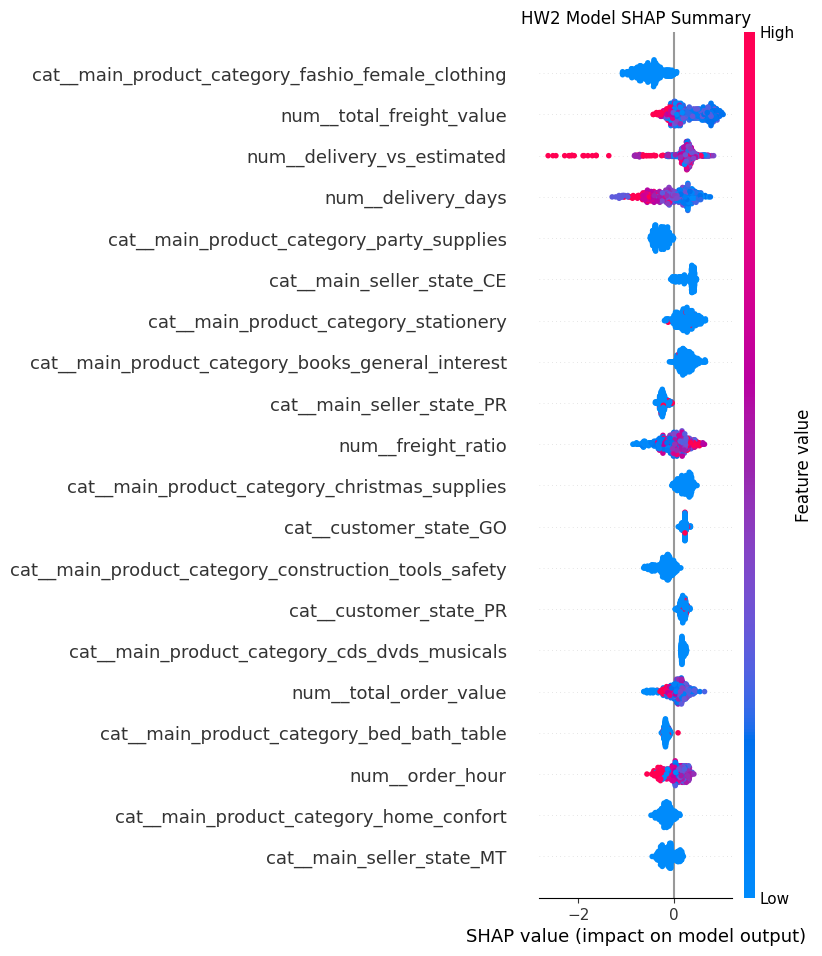

In [112]:
# hw2 shap summary

hw2_pre = xgb_tuned_pipe.named_steps["preprocess"]
hw2_model_only = xgb_tuned_pipe.named_steps["model"]

X_sample_hw2_trans = hw2_pre.transform(X_sample_hw2)

try:
    hw2_feature_names = hw2_pre.get_feature_names_out()
except:
    hw2_feature_names = [f"Feature_{i}" for i in range(X_sample_hw2_trans.shape[1])]

if hasattr(X_sample_hw2_trans, "toarray"):
    X_sample_hw2_trans_df = pd.DataFrame(
        X_sample_hw2_trans.toarray(),
        columns=hw2_feature_names,
        index=X_sample_hw2.index
    )
else:
    X_sample_hw2_trans_df = pd.DataFrame(
        X_sample_hw2_trans,
        columns=hw2_feature_names,
        index=X_sample_hw2.index
    )

explainer_hw2 = shap.TreeExplainer(hw2_model_only)
shap_values_hw2 = explainer_hw2.shap_values(X_sample_hw2_trans_df)

plt.figure()
shap.summary_plot(shap_values_hw2, X_sample_hw2_trans_df, show=False)
plt.title("HW2 Model SHAP Summary")
plt.show()

In [113]:
# auto ml prediction proba wrapper

def automl_predict_proba_class1(X_input):
    X_input_df = pd.DataFrame(X_input, columns=X_sample_auto.columns)
    proba_df = best_predictor.predict_proba(X_input_df)
    if 1 in proba_df.columns:
        return proba_df[1].values
    return proba_df.iloc[:, 1].values

In [114]:
# background sample

background_auto = X_sample_auto.sample(min(50, len(X_sample_auto)), random_state=42)
explain_auto = X_sample_auto.sample(min(100, len(X_sample_auto)), random_state=42)

print("Background shape:", background_auto.shape)
print("Explain shape:", explain_auto.shape)

Background shape: (50, 15)
Explain shape: (100, 15)


  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_15915/4011035102.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_auto, explain_auto, show=False)


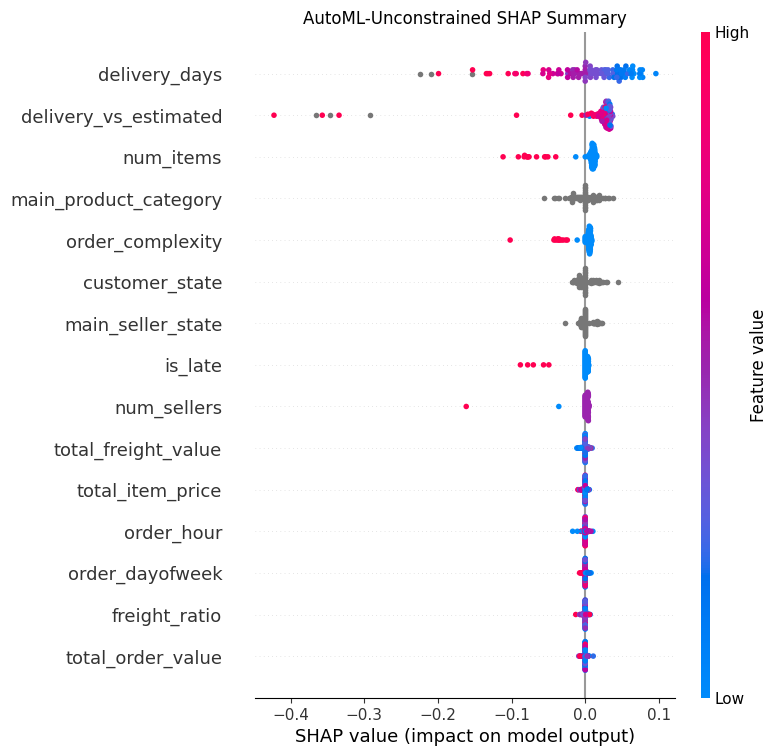

In [115]:
# automl shap summary

explainer_auto = shap.KernelExplainer(
    automl_predict_proba_class1,
    background_auto
)

shap_values_auto = explainer_auto.shap_values(explain_auto, nsamples=100)

plt.figure()
shap.summary_plot(shap_values_auto, explain_auto, show=False)
plt.title(f"{best_automl_name} SHAP Summary")
plt.show()

In [116]:
# top 5 features for hw2

try:
    hw2_feature_names = hw2_pre.get_feature_names_out()
except:
    hw2_feature_names = [f"Feature_{i}" for i in range(X_sample_hw2_trans.shape[1])]

hw2_importance = pd.DataFrame({
    "Feature": hw2_feature_names,
    "MeanAbsSHAP": np.abs(shap_values_hw2).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

display(hw2_importance.head(5))

,Feature,MeanAbsSHAP
39,cat__main_product_category_fashio_female_clothing,0.498175
5,num__total_freight_value,0.365699
1,num__delivery_vs_estimated,0.351112
0,num__delivery_days,0.328706
70,cat__main_product_category_party_supplies,0.284731


In [117]:
# top 5 for autoML

auto_importance = pd.DataFrame({
    "Feature": explain_auto.columns,
    "MeanAbsSHAP": np.abs(shap_values_auto).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

display(auto_importance.head(5))

,Feature,MeanAbsSHAP
0,delivery_days,0.048204
1,delivery_vs_estimated,0.046628
7,num_items,0.018606
9,main_product_category,0.012749
14,order_complexity,0.010098


The shap summaries for the two models show there is some overlap in the top 5 features. In both models, delivery vs estimated and delivery days show up suggesting they are learning a similar story about what drives customer satisfacton and review scores. However it is important to note the models don't rank the features in the same order. AutoML gives more attention to delivery days where hw2 emphasizes female fashion clothing category. While they have a slightly different top 5 in general, they both push predictions in a similar direction.

In [118]:
# find/get a comparison case

hw2_pred_labels = xgb_tuned_pipe.predict(X_test)

if best_automl_name == "AutoML-Constrained":
    automl_pred_labels = predictor_a.predict(X_test)
else:
    automl_pred_labels = predictor_b.predict(test_unconstrained.drop(columns=["is_positive_review"]))

compare_df = pd.DataFrame({
    "y_true": y_test,
    "hw2_pred": hw2_pred_labels,
    "automl_pred": automl_pred_labels
}, index=y_test.index)

disagreement_cases = compare_df[compare_df["hw2_pred"] != compare_df["automl_pred"]]
agreement_cases = compare_df[compare_df["hw2_pred"] == compare_df["automl_pred"]]

print("Disagreement cases:", disagreement_cases.shape[0])
print("Agreement cases:", agreement_cases.shape[0])

chosen_idx = disagreement_cases.index[0] if len(disagreement_cases) > 0 else agreement_cases.index[0]
print("Chosen index:", chosen_idx)

Disagreement cases: 180
Agreement cases: 19709
Chosen index: 60041


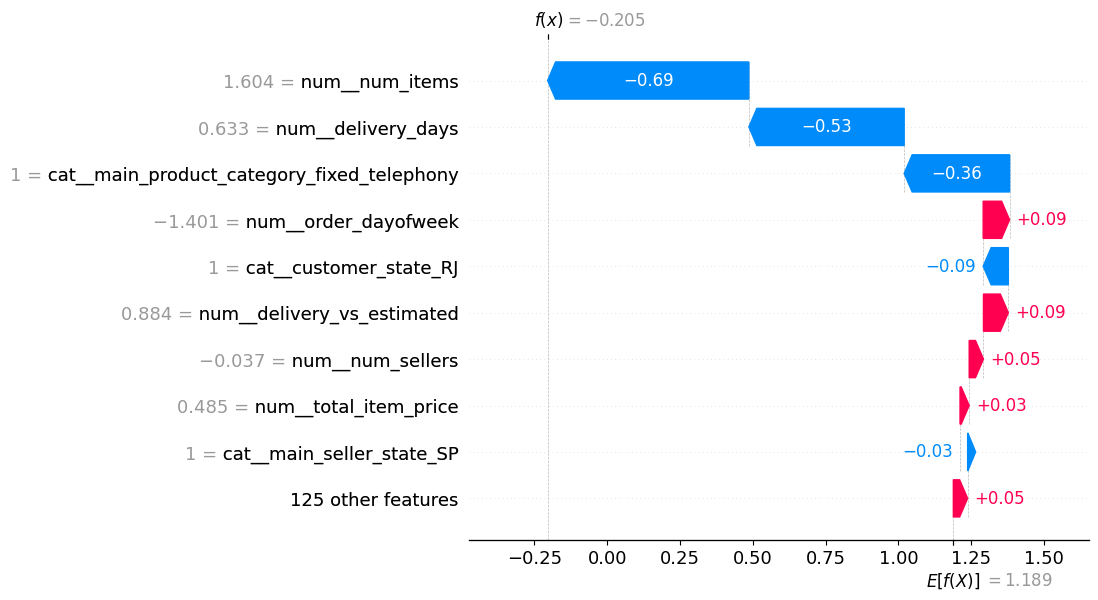

In [119]:
# hw2 waterfall plot

chosen_row_hw2 = X_test.loc[[chosen_idx]]
chosen_row_hw2_trans = hw2_pre.transform(chosen_row_hw2)

shap_value_single_hw2 = explainer_hw2.shap_values(chosen_row_hw2_trans)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_value_single_hw2[0], # Using SHAP values for class 0 (negative review)
        base_values=explainer_hw2.expected_value,
        data=chosen_row_hw2_trans.toarray().flatten(), # Convert sparse row to dense 1D array
        feature_names=hw2_feature_names
    )
)

  0%|          | 0/1 [00:00<?, ?it/s]

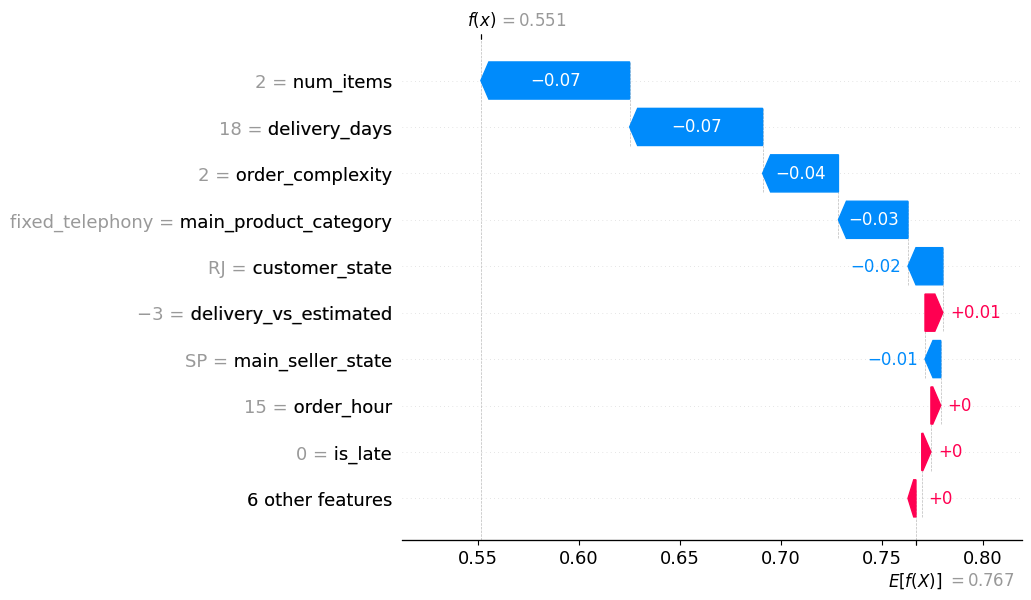

In [120]:
# autoML waterfall plot

if best_automl_name == "AutoML-Constrained":
    chosen_row_auto = X_test.loc[[chosen_idx]]
else:
    chosen_row_auto = test_unconstrained.drop(columns=["is_positive_review"]).loc[[chosen_idx]]

shap_values_single_auto = explainer_auto.shap_values(chosen_row_auto, nsamples=100)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_single_auto[0],
        base_values=explainer_auto.expected_value,
        data=chosen_row_auto.iloc[0].values,
        feature_names=chosen_row_auto.columns.tolist()
    )
)

Both models tell a similar story. In this case, there was a lot of items, and the delivery was probably late. Those are the two top features by a lot on both charts. We can also see there are many more, and larger blue features (indicating poor review) compared to the red ones. The hw2 plot includes over 130 features where as the autoML plot only uses 15, but still concludes a similar outcome.

When dealing with stakeholders, the hw2 manual model would probably be easier to explain. While still complex, it is a single model compared to the autoML model which was a weighted ensemble combining many types of models. Possible confusion and further questions or doubts could arise from multiple things being squished into one, whereas with hw2 you only have to talk about one thing. So, homework 2 model would be easier to present in general despite the slight performance disadvantage.

# Part 6: Cost-sensitive analysis

In [121]:
# false neg: $50
# false pos: $5

# original target:
      # 1 = satisfied / positive review
      # 0 = dissatisfied / negative review

from sklearn.metrics import confusion_matrix

def expected_cost_flag_dissatisfied(y_true_positive_review, p_positive_review, threshold,
                                    fn_cost=50, fp_cost=5):
    y_true_dissatisfied = (y_true_positive_review == 0).astype(int)
    p_dissatisfied = 1 - p_positive_review
    y_pred_flag = (p_dissatisfied >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_dissatisfied, y_pred_flag).ravel()
    total_cost = fn * fn_cost + fp * fp_cost

    return {
        "threshold": threshold,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "total_cost": total_cost
    }

In [122]:
# HW2 probability of positive review
hw2_proba = xgb_tuned_pipe.predict_proba(X_test)[:, 1]

# Best AutoML = AutoML-Unconstrained
automl_proba = b_proba

In [123]:
# threshold sweep

thresholds = np.arange(0.10, 0.91, 0.05)

cost_rows = []

for t in thresholds:
    hw2_cost = expected_cost_flag_dissatisfied(y_test, hw2_proba, t)
    auto_cost = expected_cost_flag_dissatisfied(y_test, automl_proba, t)

    cost_rows.append({
        "threshold": t,
        "HW2_cost": hw2_cost["total_cost"],
        "HW2_fp": hw2_cost["fp"],
        "HW2_fn": hw2_cost["fn"],
        "AutoML_cost": auto_cost["total_cost"],
        "AutoML_fp": auto_cost["fp"],
        "AutoML_fn": auto_cost["fn"]
    })

cost_df = pd.DataFrame(cost_rows)
cost_df

,threshold,HW2_cost,HW2_fp,HW2_fn,AutoML_cost,AutoML_fp,AutoML_fn
0,0.10,77185,14127,131,76430,14716,57
1,0.15,92380,7826,1065,90300,7880,1018
2,0.20,113905,3761,1902,114550,3650,1926
3,0.25,128400,2110,2357,129360,1992,2388
4,0.30,137600,1390,2613,139360,1242,2663
5,0.35,145165,953,2808,147425,815,2867
6,0.40,152155,681,2975,152880,576,3000
7,0.45,155260,522,3053,155810,462,3070
8,0.50,158150,450,3118,158225,395,3125
9,0.55,161215,393,3185,161770,344,3201


In [124]:
# cost optimal threshold

best_hw2_row = cost_df.loc[cost_df["HW2_cost"].idxmin()]
best_auto_row = cost_df.loc[cost_df["AutoML_cost"].idxmin()]

optimal_cost_df = pd.DataFrame([
    {
        "Model": "HW2 Manual",
        "Optimal_Threshold": best_hw2_row["threshold"],
        "Minimum_Total_Cost": best_hw2_row["HW2_cost"],
        "False_Positives": best_hw2_row["HW2_fp"],
        "False_Negatives": best_hw2_row["HW2_fn"]
    },
    {
        "Model": "AutoML-Unconstrained",
        "Optimal_Threshold": best_auto_row["threshold"],
        "Minimum_Total_Cost": best_auto_row["AutoML_cost"],
        "False_Positives": best_auto_row["AutoML_fp"],
        "False_Negatives": best_auto_row["AutoML_fn"]
    }
])

optimal_cost_df

,Model,Optimal_Threshold,Minimum_Total_Cost,False_Positives,False_Negatives
0,HW2 Manual,0.1,77185.0,14127.0,131.0
1,AutoML-Unconstrained,0.1,76430.0,14716.0,57.0


The optimal threshold is not different between models, with both being .1. The autoML model achieves lower cost.

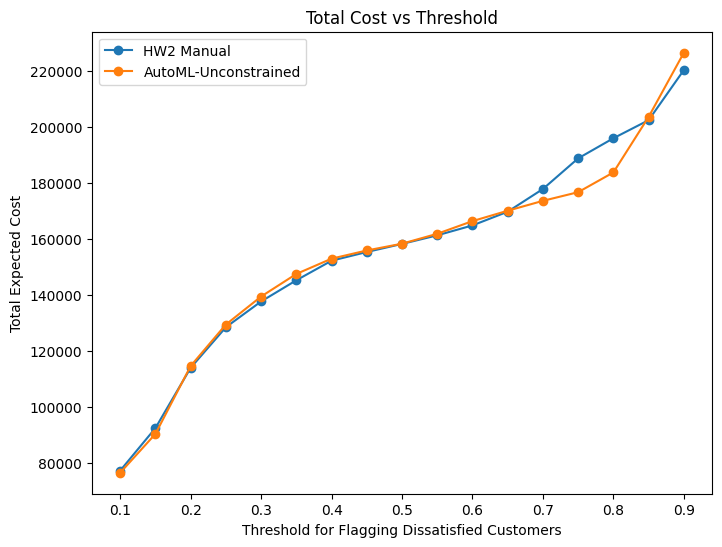

In [125]:
# cost vs threshold

plt.figure(figsize=(8, 6))
plt.plot(cost_df["threshold"], cost_df["HW2_cost"], marker="o", label="HW2 Manual")
plt.plot(cost_df["threshold"], cost_df["AutoML_cost"], marker="o", label="AutoML-Unconstrained")

plt.xlabel("Threshold for Flagging Dissatisfied Customers")
plt.ylabel("Total Expected Cost")
plt.title("Total Cost vs Threshold")
plt.legend()
plt.show()

The model with better ROC-AUC does not necessarily produce lower business cost. ROC-AUC measures how well a model does aross all thresholds, while business costs depend on performance at unique or specific thresholds and situations. For example, a model can have a better ROC-AUC score but produce higher business costs if its not as well calibrated or does poorly in the threshold the business actively is caring about.

# Part 7: Reflection

Looking back at hw2 I believe the manual work I did was extremely worth doing and was a fun learning experience along the whole process. Even though the autoML produced a slightly better model, the steps and decision making along the way has me feeling much more confident in the entire process overall. If I had just went with autoML from the start, I may have similar results but I wouldn't be able to explain them as well and I wouldn't have general knowledge of the process. I specifically like feature engineering, I think it really ties in what does the business need/want out of you and can turn the outcomes for better or worse. It tests how well the problem is understood and what tools you can create to work through it.

AutoML excelled at speed, depth and efficiency. It handled model selection well by testing multiple types and quickly identified a strong ensemble output. It also took care of much of the manual work I did in hw2 all by itself and still yielded similar results.

As good as it was autoML still has limitations. It didn't define the business problem, clean any data, or decide which variables might leak. The need for human judgement is still prevalant in evaluating calibration, interpretability and whether performance differences were meaningful in actual business decision making. Even when it found the best model, I still had to look and make sure/understand whether it was trustworthy and useful given the context.

Based on my experiences with this assignment, I would recommend using autoML when you're after a strong baseline quickly, or looking to compare and combine many models for a greater good. However I would recommend manual modeling when things like domain knowledge, feature engineering and business framing matter the most. You have more control and a deeper understanding of how things are working, and why they are producing what they are. In other words, autoML for a quicker but still efficient approach, and when details and business problems matter most stick with manual. A combined approach is also very strong, for example starting with autoML then building off of it, this will likely require the most time though.

If I were deploying either model at Olist, I would lean toward the hw2 model. While the performance and calibration are slightly better in autoML model, the difference is extremely small, not enough to change a business decision. It is also easier to explain to stakeholders and talk about the moving parts that make it up. With more control over the feature engineering I can adapt and refine it faster. The final decision would also depend on how comfortable Olist is with an ensemble model, as it does take longer to run and will be more challenging to explain what it actually did compared to all of the manual steps I took for hw2's model.



# ***HOMEWORK 4***

# Part 1: Foundation Model Exploration

In [126]:
from transformers import pipeline

In [127]:
# part 1a
# load the multilingual sentiment model

sentiment = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [128]:
# keep only reviews with actual text

reviews_text = dfs["order_reviews"].copy()

reviews_text["review_comment_message"] = reviews_text["review_comment_message"].fillna("").astype(str)

reviews_text = reviews_text[
    reviews_text["review_comment_message"].str.strip() != ""
].copy()

print("Rows with non-empty review text:", reviews_text.shape[0])
reviews_text[["order_id", "review_score", "review_comment_message"]].head()

Rows with non-empty review text: 40950


,order_id,review_score,review_comment_message
3,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.
4,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa
9,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelho esta impresso como 3desinfector e ao chegar esta com outro nome...atualizar com a marca correta uma vez que é o mesmo aparelho
12,9d6f15f95d01e79bd1349cc208361f09,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
15,e51478e7e277a83743b6f9991dbfa3fb,5,"Vendedor confiável, produto ok e entrega antes do prazo."


In [129]:
# if there are multiple review rows per order, keep one per order

reviews_text = reviews_text.sort_values("order_id").drop_duplicates(subset="order_id", keep="first").copy()

print("Unique orders with non-empty review text:", reviews_text.shape[0])

Unique orders with non-empty review text: 40809


In [130]:
# ensures the same 500 records can be used for both the foundation model and hw2 model

part1_df = order_level.merge(
    reviews_text[["order_id", "review_score", "review_comment_message"]],
    on="order_id",
    how="inner"
).copy()

print("Merged Part 1 dataset shape:", part1_df.shape)
part1_df[["order_id", "review_score", "review_comment_message"]].head()

Merged Part 1 dataset shape: (40809, 19)


,order_id,review_score,review_comment_message
0,00010242fe8c5a6d1ba2dd792cb16214,5,"Perfeito, produto entregue antes do combinado."
1,000229ec398224ef6ca0657da4fc703e,5,Chegou antes do prazo previsto e o produto surpreendeu pela qualidade. Muito satisfatório.
2,00042b26cf59d7ce69dfabb4e55b4fd9,5,Gostei pois veio no prazo determinado .
3,0005a1a1728c9d785b8e2b08b904576c,1,"Na descrição do produto quando fui efetuar a compra, estava detalhado os pentes de disfarce.\r\nQuando recebe o produto verifiquei e notei que não havia os pentes 0.5 e 1.5"
4,00061f2a7bc09da83e415a52dc8a4af1,5,"A caixa do produto veio com uma pequena avariação, mas de resto veio perfeito..."


In [131]:
# actual binary target using the same hw2 definition
# 4-5 stars = positive (1), 1-3 stars = negative (0)

part1_df["actual_binary"] = np.where(part1_df["review_score"] >= 4, 1, 0)

print("Actual class distribution in full eligible set:")
print(part1_df["actual_binary"].value_counts())

Actual class distribution in full eligible set:
actual_binary
1    26409
0    14400
Name: count, dtype: int64


In [132]:
# sample 500 records reproducibly

sample_500 = part1_df.sample(n=500, random_state=42).copy()

print("Sample shape:", sample_500.shape)
print(sample_500["actual_binary"].value_counts())

Sample shape: (500, 20)
actual_binary
1    325
0    175
Name: count, dtype: int64


In [133]:
# running the foundation model on the 500 review comments

foundation_results = []

for text in sample_500["review_comment_message"]:
    pred = sentiment(text[:512])[0]   # truncating text defensively for speed/safety
    foundation_results.append(pred)

foundation_preds = pd.DataFrame(foundation_results)
foundation_preds.head()

,label,score
0,5 stars,0.645141
1,5 stars,0.348631
2,4 stars,0.392220
3,4 stars,0.429553
4,1 star,0.852226


In [134]:
# attach predictions back to sample

sample_500 = sample_500.reset_index(drop=True)
sample_500["fm_label"] = foundation_preds["label"]
sample_500["fm_confidence"] = foundation_preds["score"]

# extract numeric stars from labels like "4 stars"

sample_500["fm_stars"] = sample_500["fm_label"].str.extract(r"(\d)").astype(int)

# map to binary target

sample_500["fm_binary"] = np.where(sample_500["fm_stars"] >= 4, 1, 0)

sample_500[[
    "review_score",
    "actual_binary",
    "fm_label",
    "fm_stars",
    "fm_confidence",
    "fm_binary"
]].head()

,review_score,actual_binary,fm_label,fm_stars,fm_confidence,fm_binary
0,4,1,5 stars,5,0.645141,1
1,5,1,5 stars,5,0.348631,1
2,5,1,4 stars,4,0.392220,1
3,4,1,4 stars,4,0.429553,1
4,1,0,1 star,1,0.852226,0


In [135]:
# report actual vs predicted class distribution for the 500-record sample

actual_dist = sample_500["actual_binary"].value_counts().sort_index()
pred_dist = sample_500["fm_binary"].value_counts().sort_index()

print("Actual class distribution (500 sample):")
print(f"Negative (0): {actual_dist.get(0, 0)}")
print(f"Positive (1): {actual_dist.get(1, 0)}")

print("\nFoundation model predicted class distribution:")
print(f"Negative (0): {pred_dist.get(0, 0)}")
print(f"Positive (1): {pred_dist.get(1, 0)}")

Actual class distribution (500 sample):
Negative (0): 175
Positive (1): 325

Foundation model predicted class distribution:
Negative (0): 235
Positive (1): 265


In [136]:
# summary table

part1a_summary = pd.DataFrame({
    "Class": ["Negative (0)", "Positive (1)"],
    "Actual Count": [
        actual_dist.get(0, 0),
        actual_dist.get(1, 0)
    ],
    "Foundation Model Predicted Count": [
        pred_dist.get(0, 0),
        pred_dist.get(1, 0)
    ]
})

part1a_summary

,Class,Actual Count,Foundation Model Predicted Count
0,Negative (0),175,235
1,Positive (1),325,265


In [137]:
# part 1b

# true labels for the 500-record sample
y_true = sample_500["actual_binary"]

# foundation model predictions already created in part 1a
y_pred_fm = sample_500["fm_binary"]

In [138]:
hw2_feature_cols = X_train.columns.tolist()

X_part1_hw2 = sample_500[hw2_feature_cols].copy()

print("hw2 feature matrix shape:", X_part1_hw2.shape)
X_part1_hw2.head()

hw2 feature matrix shape: (500, 15)


,delivery_days,delivery_vs_estimated,order_hour,order_dayofweek,total_item_price,total_freight_value,total_order_value,freight_ratio,num_items,num_sellers,order_complexity,is_late,main_product_category,main_seller_state,customer_state
0,8.0,-13.0,22,1,134.90,14.81,149.71,0.098925,1,1,1,0,bed_bath_table,SC,SC
1,7.0,-25.0,20,6,99.99,11.72,111.71,0.104915,1,1,1,0,housewares,SP,SP
2,3.0,-14.0,9,0,316.90,36.80,353.70,0.104043,2,1,2,0,auto,SP,SP
3,11.0,-29.0,14,5,74.90,15.27,90.17,0.169347,1,1,1,0,computers_accessories,SC,SP
4,7.0,-17.0,15,1,126.90,15.64,142.54,0.109724,1,1,1,0,auto,SP,MG


In [139]:
# generate hw2 model predictions on the same 500 records

y_pred_hw2 = xgb_tuned_pipe.predict(X_part1_hw2)

# predicted probabilities

y_prob_hw2 = xgb_tuned_pipe.predict_proba(X_part1_hw2)[:, 1]

print("First 10 hw2 predictions:", y_pred_hw2[:10])

First 10 hw2 predictions: [1 1 1 1 1 1 1 1 1 0]


In [140]:
# calculate metrics for both models

comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Foundation Model (review text)": [
        accuracy_score(y_true, y_pred_fm),
        precision_score(y_true, y_pred_fm),
        recall_score(y_true, y_pred_fm),
        f1_score(y_true, y_pred_fm)
    ],
    "Your HW2 Model (order features)": [
        accuracy_score(y_true, y_pred_hw2),
        precision_score(y_true, y_pred_hw2),
        recall_score(y_true, y_pred_hw2),
        f1_score(y_true, y_pred_hw2)
    ]
})

comparison_table

,Metric,Foundation Model (review text),Your HW2 Model (order features)
0,Accuracy,0.832000,0.756000
1,Precision,0.954717,0.738824
2,Recall,0.778462,0.966154
3,F1 Score,0.857627,0.837333


In [141]:
# saving the hw2 predictions back into sample_500 for later inspection

sample_500["hw2_pred"] = y_pred_hw2
sample_500["hw2_prob"] = y_prob_hw2

sample_500[[
    "order_id",
    "actual_binary",
    "fm_binary",
    "hw2_pred",
    "hw2_prob"
]].head()

,order_id,actual_binary,fm_binary,hw2_pred,hw2_prob
0,63a737026bbe83be3d56d70c83923ebd,1,1,1,0.875495
1,029c366599ce117100419a093b7f6132,1,1,1,0.852751
2,015183dcb37f19e0456905fa5aac0b69,1,1,1,0.809630
3,8e239d4b3f8da8e910f2ebf1e6aae337,1,1,1,0.829591
4,28eaf28c1a7f1e6d917f465578bb1b43,0,0,1,0.868062


Part 1c:

The foundation model performed better overall than my hw2 model. It had better accuracy, precision and a better f1 score. However, my hw2 model had much higher recall, which makes sense because the foundation model is analyzing the actual review text which comes straight from the customer containing direct emotions and details. My model uses order, shipping and other product related features to predict satisfaction before the review is created.

The zero training foundation model has clear advantages and disadvantages. It's quick to implement, and produces strong results fast. This makes it appealing in situations where data or computing time is limited. Some disadvantages include being reliant on the reviews already being written, and won't always be as specific to a business related problem that a custom model would be geared toward.

I'd recommend a foundation model when companies need a quick solution or have limited data. A custom model is better when the goal is to predict customer dissatisfaction earlier in the process. These could definitely be combined to form a powerful before review and after review team, with the custom model flagging risky orders early where the foundation model could analyze what went wrong and was maybe missed.

# Part 2: Experiment tracking with MLFlow

In [142]:
# part 2a

import mlflow
import mlflow.sklearn

In [143]:
# create/set the experiment

mlflow.set_experiment("olist-satisfaction")

2026/04/21 21:45:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/21 21:45:44 INFO mlflow.store.db.utils: Updating database tables
2026/04/21 21:45:46 INFO mlflow.tracking.fluent: Experiment with name 'olist-satisfaction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1776807946308, experiment_id='1', last_update_time=1776807946308, lifecycle_stage='active', name='olist-satisfaction', tags={}, trace_location=None, workspace='default'>

In [144]:
def log_model_run(model_name, model_object, X_eval, y_eval, params_dict):

    # logs one MLflow run with parameters, metrics, and the model artifact

    with mlflow.start_run(run_name=model_name):
        # predictions
        y_pred = model_object.predict(X_eval)
        y_prob = model_object.predict_proba(X_eval)[:, 1]

        # metrics
        acc = accuracy_score(y_eval, y_pred)
        prec = precision_score(y_eval, y_pred)
        rec = recall_score(y_eval, y_pred)
        f1 = f1_score(y_eval, y_pred)
        auc = roc_auc_score(y_eval, y_prob)

        # log params
        mlflow.log_param("model_type", model_name)
        for key, value in params_dict.items():
            mlflow.log_param(key, value)

        # log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("roc_auc", auc)

        # log model artifact
        mlflow.sklearn.log_model(model_object, artifact_path="model")

        print(f"Logged run: {model_name}")
        print({
            "accuracy": round(acc, 4),
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1": round(f1, 4),
            "roc_auc": round(auc, 4)
        })

In [145]:
# example run 1: tuned XGBoost pipeline
log_model_run(
    model_name="xgboost_tuned",
    model_object=xgb_tuned_pipe,
    X_eval=X_test,
    y_eval=y_test,
    params_dict={
        "algorithm": "XGBoost",
        "tuned": True
    }
)

2026/04/21 21:45:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 21:45:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: xgboost_tuned
{'accuracy': 0.8206, 'precision': 0.8256, 'recall': 0.9704, 'f1': 0.8921, 'roc_auc': np.float64(0.7326)}


In [146]:
# example run 2: random forest
log_model_run(
    model_name="random_forest",
    model_object=rf_pipeline,
    X_eval=X_test,
    y_eval=y_test,
    params_dict={
        "algorithm": "RandomForest",
        "tuned": False
    }
)

2026/04/21 21:45:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 21:45:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: random_forest
{'accuracy': 0.8128, 'precision': 0.8204, 'recall': 0.9667, 'f1': 0.8876, 'roc_auc': np.float64(0.7159)}


In [147]:
log_model_run(
    model_name="xgboost_tuned",
    model_object=xgb_tuned_pipe,
    X_eval=X_test,
    y_eval=y_test,
    params_dict={
        "algorithm": "XGBoost",
        "tuned": True
    }
)

log_model_run(
    model_name="random_forest",
    model_object=rf_pipeline,
    X_eval=X_test,
    y_eval=y_test,
    params_dict={
        "algorithm": "RandomForest",
        "max_iter": 1000
    }
)

2026/04/21 21:46:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 21:46:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: xgboost_tuned
{'accuracy': 0.8206, 'precision': 0.8256, 'recall': 0.9704, 'f1': 0.8921, 'roc_auc': np.float64(0.7326)}


2026/04/21 21:46:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 21:46:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged run: random_forest
{'accuracy': 0.8128, 'precision': 0.8204, 'recall': 0.9667, 'f1': 0.8876, 'roc_auc': np.float64(0.7159)}


In [148]:
# view logged runs in a dataframe
runs_df = mlflow.search_runs(experiment_names=["olist-satisfaction"])
runs_df[[
    "run_id",
    "tags.mlflow.runName",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.roc_auc"
]]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,4357926f33ab4f88b0d6bd0182075c61,random_forest,0.812761,0.820440,0.966658,0.887567,0.715924
1,78fb7d37f5d6492fa9cca973063dd155,xgboost_tuned,0.820604,0.825557,0.970406,0.892140,0.732556
2,1ee5f18c3bb447d1853f9e7b14c89edb,random_forest,0.812761,0.820440,0.966658,0.887567,0.715924
3,59f3356806c24d2c88c56f58e6d160f2,xgboost_tuned,0.820604,0.825557,0.970406,0.892140,0.732556


In [149]:
# part 2b

!mkdir -p /content/mlartifacts

!mlflow server \
  --backend-store-uri sqlite:////content/mlflow.db \
  --default-artifact-root file:///content/mlartifacts \
  --host 0.0.0.0 \
  --port 5001 \
  --disable-security-middleware \
  &>/content/mlflow_server.log &

In [150]:
!tail -50 /content/mlflow_server.log

In [151]:
mlflow.set_tracking_uri("http://127.0.0.1:5001")
mlflow.set_experiment("olist-satisfaction")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: http://127.0.0.1:5001


In [152]:
runs_df = mlflow.search_runs(experiment_names=["olist-satisfaction"])
runs_df[[
    "run_id",
    "tags.mlflow.runName",
    "metrics.accuracy",
    "metrics.precision",
    "metrics.recall",
    "metrics.f1",
    "metrics.roc_auc"
]]

,run_id,tags.mlflow.runName,metrics.accuracy,metrics.precision,metrics.recall,metrics.f1,metrics.roc_auc
0,4357926f33ab4f88b0d6bd0182075c61,random_forest,0.812761,0.820440,0.966658,0.887567,0.715924
1,78fb7d37f5d6492fa9cca973063dd155,xgboost_tuned,0.820604,0.825557,0.970406,0.892140,0.732556
2,1ee5f18c3bb447d1853f9e7b14c89edb,random_forest,0.812761,0.820440,0.966658,0.887567,0.715924
3,59f3356806c24d2c88c56f58e6d160f2,xgboost_tuned,0.820604,0.825557,0.970406,0.892140,0.732556


In [153]:
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5001)"))

https://5001-m-s-kkb-usw3b1-51e0rdwaepa3-b.us-west3-1.prod.colab.dev


In [154]:
# registering the model

mlflow.set_tracking_uri("http://127.0.0.1:5001")

best_run_id = "00ff6471106d4b2a98115fb44e024d17"
model_uri = f"runs:/{best_run_id}/model"

result = mlflow.register_model(
    model_uri=model_uri,
    name="olist-satisfaction-model"
)

print("Registered model:", result.name)
print("Version:", result.version)

Successfully registered model 'olist-satisfaction-model'.


RestException: RESOURCE_DOES_NOT_EXIST: Run with id=00ff6471106d4b2a98115fb44e024d17 not found

In [ ]:
# move it to production

from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri="http://127.0.0.1:5001")

client.transition_model_version_stage(
    name="olist-satisfaction-model",
    version=result.version,
    stage="Production"
)

print("Model moved to Production.")

# Part 3: Model serving API

In [ ]:
import os
import json
import joblib

os.makedirs("model", exist_ok=True)

# save the trained pipeline
joblib.dump(xgb_tuned_pipe, "model/model.pkl")

# exact feature schema
schema = {
    "required_features": [
        "delivery_days",
        "delivery_vs_estimated",
        "order_hour",
        "order_dayofweek",
        "total_item_price",
        "total_freight_value",
        "total_order_value",
        "freight_ratio",
        "num_items",
        "num_sellers",
        "order_complexity",
        "is_late",
        "main_product_category",
        "main_seller_state",
        "customer_state"
    ],
    "numeric_features": [
        "delivery_days",
        "delivery_vs_estimated",
        "order_hour",
        "order_dayofweek",
        "total_item_price",
        "total_freight_value",
        "total_order_value",
        "freight_ratio",
        "num_items",
        "num_sellers",
        "order_complexity",
        "is_late"
    ],
    "categorical_features": [
        "main_product_category",
        "main_seller_state",
        "customer_state"
    ],
    "allowed_categories": {
        "main_product_category": sorted(X_train["main_product_category"].dropna().astype(str).unique().tolist()),
        "main_seller_state": sorted(X_train["main_seller_state"].dropna().astype(str).unique().tolist()),
        "customer_state": sorted(X_train["customer_state"].dropna().astype(str).unique().tolist())
    }
}

with open("model/schema.json", "w") as f:
    json.dump(schema, f, indent=2)

print("Saved:")
print("- model/model.pkl")
print("- model/schema.json")

In [ ]:
!ls model

In [ ]:
# create app.py

%%writefile app.py
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import json

app = Flask(__name__)

MODEL_PATH = "model/model.pkl"
SCHEMA_PATH = "model/schema.json"

model = joblib.load(MODEL_PATH)

with open(SCHEMA_PATH, "r") as f:
    schema = json.load(f)

REQUIRED_FEATURES = schema["required_features"]
NUMERIC_FEATURES = schema["numeric_features"]
CATEGORICAL_FEATURES = schema["categorical_features"]
ALLOWED_CATEGORIES = schema["allowed_categories"]


def validate_record(record):
    errors = {}

    missing = [col for col in REQUIRED_FEATURES if col not in record]
    if missing:
        errors["missing_fields"] = missing
        return errors

    for col in NUMERIC_FEATURES:
        value = record.get(col)

        try:
            value = float(value)
        except (TypeError, ValueError):
            errors[col] = "must be a numeric value"
            continue

        if col in ["total_item_price", "total_freight_value", "total_order_value", "freight_ratio"]:
            if value < 0:
                errors[col] = "must be a non-negative number"

        if col in ["num_items", "num_sellers", "order_complexity"]:
            if value < 0:
                errors[col] = "must be a non-negative number"

        if col == "order_hour" and not (0 <= value <= 23):
            errors[col] = "must be between 0 and 23"

        if col == "order_dayofweek" and not (0 <= value <= 6):
            errors[col] = "must be between 0 and 6"

        if col == "is_late" and value not in [0, 1]:
            errors[col] = "must be 0 or 1"

    for col in CATEGORICAL_FEATURES:
        value = str(record.get(col))
        if value not in ALLOWED_CATEGORIES[col]:
            errors[col] = f"unrecognized value '{value}'"

    return errors


def prepare_dataframe(records):
    df = pd.DataFrame(records)
    df = df[REQUIRED_FEATURES].copy()

    for col in NUMERIC_FEATURES:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in CATEGORICAL_FEATURES:
        df[col] = df[col].astype(str)

    return df


@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "healthy", "model": "loaded"})


@app.route("/predict", methods=["POST"])
def predict():
    if not request.is_json:
        return jsonify({"error": "Invalid input", "details": "Request body must be valid JSON"}), 400

    data = request.get_json()

    if not isinstance(data, dict):
        return jsonify({"error": "Invalid input", "details": "Request body must be a JSON object"}), 400

    errors = validate_record(data)
    if errors:
        return jsonify({"error": "Invalid input", "details": errors}), 400

    df = prepare_dataframe([data])

    pred = int(model.predict(df)[0])
    prob = float(model.predict_proba(df)[0, 1])
    label = "positive" if pred == 1 else "negative"

    return jsonify({
        "prediction": pred,
        "probability": round(prob, 4),
        "label": label
    })


@app.route("/predict/batch", methods=["POST"])
def predict_batch():
    if not request.is_json:
        return jsonify({"error": "Invalid input", "details": "Request body must be valid JSON"}), 400

    data = request.get_json()

    if not isinstance(data, list):
        return jsonify({"error": "Invalid input", "details": "Request body must be a JSON array of records"}), 400

    if len(data) == 0:
        return jsonify({"error": "Invalid input", "details": "Batch request cannot be empty"}), 400

    if len(data) > 100:
        return jsonify({"error": "Invalid input", "details": "Batch size cannot exceed 100 records"}), 400

    batch_errors = {}
    for i, record in enumerate(data):
        if not isinstance(record, dict):
            batch_errors[f"record_{i}"] = "must be a JSON object"
            continue

        record_errors = validate_record(record)
        if record_errors:
            batch_errors[f"record_{i}"] = record_errors

    if batch_errors:
        return jsonify({"error": "Invalid input", "details": batch_errors}), 400

    df = prepare_dataframe(data)

    preds = model.predict(df)
    probs = model.predict_proba(df)[:, 1]

    results = []
    for pred, prob in zip(preds, probs):
        pred = int(pred)
        results.append({
            "prediction": pred,
            "probability": round(float(prob), 4),
            "label": "positive" if pred == 1 else "negative"
        })

    return jsonify({
        "count": len(results),
        "predictions": results
    })


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

In [ ]:
# create test_api.py

%%writefile test_api.py
import requests

BASE_URL = "http://127.0.0.1:5000"

valid_record = {
    "delivery_days": 8.0,
    "delivery_vs_estimated": -15.0,
    "order_hour": 14,
    "order_dayofweek": 2,
    "total_item_price": 278.99,
    "total_freight_value": 28.03,
    "total_order_value": 307.02,
    "freight_ratio": 0.09129698390984302,
    "num_items": 1,
    "num_sellers": 1,
    "order_complexity": 1,
    "is_late": 0,
    "main_product_category": "cool_stuff",
    "main_seller_state": "ES",
    "customer_state": "PR"
}

def print_result(test_name, passed, response=None):
    status = "PASS" if passed else "FAIL"
    print(f"{test_name}: {status}")
    if response is not None:
        try:
            print(json.dumps(response.json(), indent=2))
        except Exception:
            print(response.text)
    print("-" * 60)

# Test 1
try:
    r = requests.get(f"{BASE_URL}/health")
    passed = r.status_code == 200 and "status" in r.json() and "model" in r.json()
    print_result("Test 1 - GET /health", passed, r)
except Exception as e:
    print_result("Test 1 - GET /health", False)
    print(e)
    print("-" * 60)

# Test 2
try:
    r = requests.post(f"{BASE_URL}/predict", json=valid_record)
    passed = r.status_code == 200 and "prediction" in r.json() and "probability" in r.json() and "label" in r.json()
    print_result("Test 2 - POST /predict valid request", passed, r)
except Exception as e:
    print_result("Test 2 - POST /predict valid request", False)
    print(e)
    print("-" * 60)

# Test 3
try:
    batch_payload = [valid_record.copy() for _ in range(5)]
    r = requests.post(f"{BASE_URL}/predict/batch", json=batch_payload)
    passed = r.status_code == 200 and "predictions" in r.json() and len(r.json()["predictions"]) == 5
    print_result("Test 3 - POST /predict/batch valid batch", passed, r)
except Exception as e:
    print_result("Test 3 - POST /predict/batch valid batch", False)
    print(e)
    print("-" * 60)

# Test 4
try:
    missing_field_record = valid_record.copy()
    del missing_field_record["delivery_days"]
    r = requests.post(f"{BASE_URL}/predict", json=missing_field_record)
    passed = r.status_code == 400 and "error" in r.json() and "details" in r.json()
    print_result("Test 4 - POST /predict missing field", passed, r)
except Exception as e:
    print_result("Test 4 - POST /predict missing field", False)
    print(e)
    print("-" * 60)

# Test 5
try:
    invalid_type_record = valid_record.copy()
    invalid_type_record["total_item_price"] = "not_a_number"
    r = requests.post(f"{BASE_URL}/predict", json=invalid_type_record)
    passed = r.status_code == 400 and "error" in r.json() and "details" in r.json()
    print_result("Test 5 - POST /predict invalid type", passed, r)
except Exception as e:
    print_result("Test 5 - POST /predict invalid type", False)
    print(e)
    print("-" * 60)

In [ ]:
import os
os.makedirs("hw4-mlops/model", exist_ok=True)

In [ ]:
!cp app.py hw4-mlops/
!cp test_api.py hw4-mlops/
!cp model/model.pkl hw4-mlops/model/
!cp model/schema.json hw4-mlops/model/

In [ ]:
!zip -r hw4-mlops.zip hw4-mlops

In [ ]:
from google.colab import files
files.download("hw4-mlops.zip")

# Part 4: Docker

In [ ]:
# NO CODE

# Part 5: Monitoring and drift detection

In [155]:
import pandas as pd
import numpy as np

# combine training features and labels into one base dataset
train_base = X_train.copy()
train_base["actual_label"] = y_train.values

print(train_base.shape)
train_base.head()

(79552, 16)


,delivery_days,delivery_vs_estimated,order_hour,order_dayofweek,total_item_price,total_freight_value,total_order_value,freight_ratio,num_items,num_sellers,order_complexity,is_late,main_product_category,main_seller_state,customer_state,actual_label
75789,8.0,-15.0,14,2,278.99,28.03,307.02,0.091297,1,1,1,0,cool_stuff,ES,PR,1
48982,19.0,-10.0,17,0,153.00,33.52,186.52,0.179713,1,1,1,0,bed_bath_table,SP,PE,1
67752,27.0,5.0,19,2,147.90,15.79,163.69,0.096463,1,1,1,1,health_beauty,SP,MG,0
32224,NaN,NaN,20,3,0.00,0.00,0.00,NaN,0,0,0,0,NaN,NaN,SP,1
45723,25.0,1.0,9,6,49.99,16.92,66.91,0.252877,1,1,1,1,stationery,DF,SP,0


In [156]:
numeric_features = [
    "delivery_days",
    "delivery_vs_estimated",
    "order_hour",
    "order_dayofweek",
    "total_item_price",
    "total_freight_value",
    "total_order_value",
    "freight_ratio",
    "num_items",
    "num_sellers",
    "order_complexity",
    "is_late"
]

categorical_features = [
    "main_product_category",
    "main_seller_state",
    "customer_state"
]

In [158]:
def add_stable_noise(df, numeric_cols, noise_pct=0.05, seed=42):
    rng = np.random.default_rng(seed)
    df = df.copy()

    for col in numeric_cols:
        noise = rng.uniform(-noise_pct, noise_pct, size=len(df))


        df[col] = df[col] * (1 + noise)

    # keep some fields in valid ranges / reasonable integer form
    df["order_hour"] = df["order_hour"].round().clip(0, 23)
    df["order_dayofweek"] = df["order_dayofweek"].round().clip(0, 6)
    df["num_items"] = df["num_items"].round().clip(lower=0)
    df["num_sellers"] = df["num_sellers"].round().clip(lower=0)
    df["order_complexity"] = df["order_complexity"].round().clip(lower=0)
    df["is_late"] = df["is_late"].round().clip(0, 1)

    # non negative business values
    non_negative_cols = [
        "delivery_days",
        "total_item_price",
        "total_freight_value",
        "total_order_value",
        "freight_ratio"
    ]
    for col in non_negative_cols:
        df[col] = df[col].clip(lower=0)

    return df

In [159]:
def increase_category_share(df, category_col, target_category, increase_pct, seed=42):
    rng = np.random.default_rng(seed)
    df = df.copy()

    current_share = (df[category_col].astype(str) == target_category).mean()
    target_share = min(current_share + increase_pct, 1.0)

    current_count = (df[category_col].astype(str) == target_category).sum()
    target_count = int(round(target_share * len(df)))
    additional_needed = max(target_count - current_count, 0)

    if additional_needed > 0:
        non_target_idx = df.index[df[category_col].astype(str) != target_category].tolist()
        if len(non_target_idx) > 0:
            chosen_idx = rng.choice(
                non_target_idx,
                size=min(additional_needed, len(non_target_idx)),
                replace=False
            )
            df.loc[chosen_idx, category_col] = target_category

    return df

In [160]:
def flip_positive_to_negative(df, label_col="actual_label", flip_pct=0.05, seed=42):
    rng = np.random.default_rng(seed)
    df = df.copy()

    positive_idx = df.index[df[label_col] == 1].tolist()
    n_flip = int(round(len(positive_idx) * flip_pct))

    if n_flip > 0:
        flip_idx = rng.choice(positive_idx, size=n_flip, replace=False)
        df.loc[flip_idx, label_col] = 0

    return df

In [161]:
# generate 6 months

monthly_dfs = []

month_settings = {
    1: {"delivery_shift": 0, "freight_multiplier": 1.00, "electronics_increase": 0.00, "flip_pct": 0.00},
    2: {"delivery_shift": 0, "freight_multiplier": 1.00, "electronics_increase": 0.00, "flip_pct": 0.00},
    3: {"delivery_shift": 0, "freight_multiplier": 1.00, "electronics_increase": 0.00, "flip_pct": 0.00},
    4: {"delivery_shift": 2, "freight_multiplier": 1.15, "electronics_increase": 0.10, "flip_pct": 0.05},
    5: {"delivery_shift": 4, "freight_multiplier": 1.30, "electronics_increase": 0.15, "flip_pct": 0.05},
    6: {"delivery_shift": 6, "freight_multiplier": 1.50, "electronics_increase": 0.20, "flip_pct": 0.05},
}

for month in range(1, 7):
    settings = month_settings[month]

    # sample about 3000 records from training data
    month_df = train_base.sample(n=3000, replace=True, random_state=42 + month).copy()

    # add natural variation to all numeric fields in all months
    month_df = add_stable_noise(
        month_df,
        numeric_cols=numeric_features,
        noise_pct=0.05,
        seed=100 + month
    )

    # months 4-6: introduce drift
    if month >= 4:
        month_df["delivery_days"] = month_df["delivery_days"] + settings["delivery_shift"]
        month_df["delivery_days"] = month_df["delivery_days"].clip(lower=0)

        month_df["total_freight_value"] = month_df["total_freight_value"] * settings["freight_multiplier"]
        month_df["total_freight_value"] = month_df["total_freight_value"].clip(lower=0)

        # keep total_order_value somewhat aligned with freight changes
        month_df["total_order_value"] = month_df["total_item_price"] + month_df["total_freight_value"]

        # recompute freight_ratio safely
        month_df["freight_ratio"] = np.where(
            month_df["total_order_value"] > 0,
            month_df["total_freight_value"] / month_df["total_order_value"],
            0
        )

        # category drift
        if "electronics" in month_df["main_product_category"].astype(str).unique():
            month_df = increase_category_share(
                month_df,
                category_col="main_product_category",
                target_category="electronics",
                increase_pct=settings["electronics_increase"],
                seed=200 + month
            )

        # concept drift-like label flipping
        month_df = flip_positive_to_negative(
            month_df,
            label_col="actual_label",
            flip_pct=settings["flip_pct"],
            seed=300 + month
        )

    month_df["month"] = month
    monthly_dfs.append(month_df)

production_df = pd.concat(monthly_dfs, ignore_index=True)

print(production_df.shape)
production_df.head()

(18000, 17)


,delivery_days,delivery_vs_estimated,order_hour,order_dayofweek,total_item_price,total_freight_value,total_order_value,freight_ratio,num_items,num_sellers,order_complexity,is_late,main_product_category,main_seller_state,customer_state,actual_label,month
0,NaN,NaN,18.0,0.0,134.491057,12.388534,149.999082,0.088560,1.0,1.0,1.0,0.0,health_beauty,SP,SP,0,1
1,6.901595,-11.072988,17.0,0.0,251.796630,38.270323,287.940306,0.126613,1.0,1.0,1.0,0.0,auto,MG,RJ,1,1
2,6.170883,-10.331484,13.0,1.0,113.014496,8.863456,122.398686,0.075872,1.0,1.0,1.0,0.0,sports_leisure,SP,SP,1,1
3,10.091278,-21.614953,12.0,4.0,52.313211,23.940871,74.474898,0.301758,1.0,1.0,1.0,0.0,health_beauty,SP,DF,1,1
4,1.958866,-11.115215,9.0,1.0,204.562540,37.360889,239.118325,0.154523,1.0,1.0,1.0,0.0,furniture_decor,SP,SP,1,1


In [162]:
production_df["month"].value_counts().sort_index()

,count
month,
1,3000
2,3000
3,3000
4,3000
5,3000
6,3000


In [163]:
# check

summary_check = production_df.groupby("month").agg({
    "delivery_days": "mean",
    "total_freight_value": "mean",
    "actual_label": "mean"
}).round(3)

summary_check

,delivery_days,total_freight_value,actual_label
month,,,
1,12.021,23.151,0.776
2,12.117,22.716,0.757
3,12.154,23.105,0.757
4,13.894,26.437,0.718
5,16.187,30.053,0.710
6,17.976,33.267,0.719


In [164]:
electronics_share = (
    production_df.assign(
        is_electronics=(production_df["main_product_category"].astype(str) == "electronics").astype(int)
    )
    .groupby("month")["is_electronics"]
    .mean()
    .round(3)
)

electronics_share

,is_electronics
month,
1,0.021
2,0.023
3,0.023
4,0.129
5,0.178
6,0.235


In [166]:
# part 5b

from scipy.stats import ks_2samp

In [167]:
reference_df = X_train.copy()

features_for_drift = [
    "delivery_days",
    "total_freight_value",
    "total_item_price"
]

reference_df[features_for_drift].describe()

,delivery_days,total_freight_value,total_item_price
count,77166.000000,79552.000000,79552.000000
mean,12.091608,22.662270,137.085154
std,9.572383,21.913232,211.964134
min,0.000000,0.000000,0.000000
25%,6.000000,13.710000,45.000000
50%,10.000000,17.090000,85.500000
75%,15.000000,23.980000,149.900000
max,209.000000,1794.960000,13440.000000


In [168]:
def calculate_psi(expected, actual, bins=10, eps=0.0001):
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    min_val = min(expected.min(), actual.min())
    max_val = max(expected.max(), actual.max())

    if min_val == max_val:
        return 0.0

    bin_edges = np.linspace(min_val, max_val, bins + 1)

    expected_counts, _ = np.histogram(expected, bins=bin_edges)
    actual_counts, _ = np.histogram(actual, bins=bin_edges)

    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()

    expected_pct = np.where(expected_pct == 0, eps, expected_pct)
    actual_pct = np.where(actual_pct == 0, eps, actual_pct)

    psi = np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))
    return psi

In [169]:
def psi_flag(psi):
    if psi < 0.1:
        return "No significant drift"
    elif psi < 0.2:
        return "Moderate drift"
    else:
        return "Significant drift"

In [170]:
psi_records = []

for feature in features_for_drift:
    ref_values = reference_df[feature]

    for month in range(1, 7):
        month_values = production_df.loc[production_df["month"] == month, feature]

        psi_value = calculate_psi(ref_values, month_values, bins=10)

        psi_records.append({
            "feature": feature,
            "month": month,
            "psi": psi_value,
            "psi_flag": psi_flag(psi_value)
        })

psi_results = pd.DataFrame(psi_records)
psi_results.head(10)

,feature,month,psi,psi_flag
0,delivery_days,1,0.000873,No significant drift
1,delivery_days,2,0.001634,No significant drift
2,delivery_days,3,0.001890,No significant drift
3,delivery_days,4,0.006219,No significant drift
4,delivery_days,5,0.040439,No significant drift
5,delivery_days,6,0.111623,Moderate drift
6,total_freight_value,1,0.000596,No significant drift
7,total_freight_value,2,0.000647,No significant drift
8,total_freight_value,3,0.001832,No significant drift
9,total_freight_value,4,0.002471,No significant drift


In [171]:
psi_summary = psi_results.pivot(index="feature", columns="month", values="psi").round(4)
psi_summary

month,1,2,3,4,5,6
feature,,,,,,
delivery_days,0.0009,0.0016,0.0019,0.0062,0.0404,0.1116
total_freight_value,0.0006,0.0006,0.0018,0.0025,0.0058,0.0059
total_item_price,0.0009,0.0011,0.0028,0.0013,0.0032,0.0008


In [172]:
psi_flag_summary = psi_results.pivot(index="feature", columns="month", values="psi_flag")
psi_flag_summary

month,1,2,3,4,5,6
feature,,,,,,
delivery_days,No significant drift,No significant drift,No significant drift,No significant drift,No significant drift,Moderate drift
total_freight_value,No significant drift,No significant drift,No significant drift,No significant drift,No significant drift,No significant drift
total_item_price,No significant drift,No significant drift,No significant drift,No significant drift,No significant drift,No significant drift


In [173]:
def color_psi(val):
    if val < 0.1:
        return "background-color: lightgreen"
    elif val < 0.2:
        return "background-color: khaki"
    else:
        return "background-color: lightcoral"

psi_summary.style.map(color_psi)

month,1,2,3,4,5,6
feature,,,,,,
delivery_days,0.000900,0.001600,0.001900,0.006200,0.040400,0.111600
total_freight_value,0.000600,0.000600,0.001800,0.002500,0.005800,0.005900
total_item_price,0.000900,0.001100,0.002800,0.001300,0.003200,0.000800


In [174]:
ks_records = []

for feature in features_for_drift:
    ref_values = reference_df[feature].dropna()

    for month in range(1, 7):
        month_values = production_df.loc[production_df["month"] == month, feature].dropna()

        ks_stat, p_value = ks_2samp(ref_values, month_values)

        ks_records.append({
            "feature": feature,
            "month": month,
            "ks_statistic": ks_stat,
            "p_value": p_value,
            "significant_change": "Yes" if p_value < 0.05 else "No"
        })

ks_results = pd.DataFrame(ks_records)
ks_results.head(10)

,feature,month,ks_statistic,p_value,significant_change
0,delivery_days,1,0.044088,3.610171e-05,Yes
1,delivery_days,2,0.042138,9.381334e-05,Yes
2,delivery_days,3,0.048050,4.200934e-06,Yes
3,delivery_days,4,0.182651,5.206600e-83,Yes
4,delivery_days,5,0.295834,1.867387e-217,Yes
5,delivery_days,6,0.426985,0.000000e+00,Yes
6,total_freight_value,1,0.032708,4.024946e-03,Yes
7,total_freight_value,2,0.031967,5.312257e-03,Yes
8,total_freight_value,3,0.031907,5.433172e-03,Yes
9,total_freight_value,4,0.184815,6.610671e-87,Yes


In [175]:
ks_stat_summary = ks_results.pivot(index="feature", columns="month", values="ks_statistic").round(4)
ks_stat_summary

month,1,2,3,4,5,6
feature,,,,,,
delivery_days,0.0441,0.0421,0.0481,0.1827,0.2958,0.4270
total_freight_value,0.0327,0.0320,0.0319,0.1848,0.3051,0.4195
total_item_price,0.0222,0.0239,0.0329,0.0336,0.0257,0.0222


In [176]:
ks_pvalue_summary = ks_results.pivot(index="feature", columns="month", values="p_value")
ks_pvalue_summary = ks_pvalue_summary.applymap(lambda x: f"{x:.4g}")
ks_pvalue_summary

/tmp/ipykernel_15915/3727491712.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ks_pvalue_summary = ks_pvalue_summary.applymap(lambda x: f"{x:.4g}")


month,1,2,3,4,5,6
feature,,,,,,
delivery_days,3.61e-05,9.381e-05,4.201e-06,5.207e-83,1.867e-217,0
total_freight_value,0.004025,0.005312,0.005433,6.611e-87,2.944e-239,0
total_item_price,0.1145,0.07262,0.003702,0.002864,0.04372,0.1146


In [177]:
# significance flags

ks_sig_summary = ks_results.pivot(index="feature", columns="month", values="significant_change")
ks_sig_summary

month,1,2,3,4,5,6
feature,,,,,,
delivery_days,Yes,Yes,Yes,Yes,Yes,Yes
total_freight_value,Yes,Yes,Yes,Yes,Yes,Yes
total_item_price,No,No,Yes,Yes,Yes,No


In [178]:
drift_results = psi_results.merge(
    ks_results,
    on=["feature", "month"],
    how="inner"
)

drift_results = drift_results.sort_values(["feature", "month"]).reset_index(drop=True)
drift_results

,feature,month,psi,psi_flag,ks_statistic,p_value,significant_change
0,delivery_days,1,0.000873,No significant drift,0.044088,3.610171e-05,Yes
1,delivery_days,2,0.001634,No significant drift,0.042138,9.381334e-05,Yes
2,delivery_days,3,0.001890,No significant drift,0.048050,4.200934e-06,Yes
3,delivery_days,4,0.006219,No significant drift,0.182651,5.206600e-83,Yes
4,delivery_days,5,0.040439,No significant drift,0.295834,1.867387e-217,Yes
5,delivery_days,6,0.111623,Moderate drift,0.426985,0.000000e+00,Yes
6,total_freight_value,1,0.000596,No significant drift,0.032708,4.024946e-03,Yes
7,total_freight_value,2,0.000647,No significant drift,0.031967,5.312257e-03,Yes
8,total_freight_value,3,0.001832,No significant drift,0.031907,5.433172e-03,Yes
9,total_freight_value,4,0.002471,No significant drift,0.184815,6.610671e-87,Yes


In [179]:
# part 5c

feature_cols = X_train.columns.tolist()

X_production = production_df[feature_cols].copy()
y_production = production_df["actual_label"].copy()

print(X_production.shape)
print(y_production.shape)

(18000, 15)
(18000,)


In [180]:
production_pred = xgb_tuned_pipe.predict(X_production)
production_prob = xgb_tuned_pipe.predict_proba(X_production)[:, 1]

production_scored = production_df.copy()
production_scored["predicted_label"] = production_pred
production_scored["predicted_prob"] = production_prob

production_scored.head()

,delivery_days,delivery_vs_estimated,order_hour,order_dayofweek,total_item_price,total_freight_value,total_order_value,freight_ratio,num_items,num_sellers,order_complexity,is_late,main_product_category,main_seller_state,customer_state,actual_label,month,predicted_label,predicted_prob
0,NaN,NaN,18.0,0.0,134.491057,12.388534,149.999082,0.088560,1.0,1.0,1.0,0.0,health_beauty,SP,SP,0,1,0,0.284033
1,6.901595,-11.072988,17.0,0.0,251.796630,38.270323,287.940306,0.126613,1.0,1.0,1.0,0.0,auto,MG,RJ,1,1,1,0.878645
2,6.170883,-10.331484,13.0,1.0,113.014496,8.863456,122.398686,0.075872,1.0,1.0,1.0,0.0,sports_leisure,SP,SP,1,1,1,0.882907
3,10.091278,-21.614953,12.0,4.0,52.313211,23.940871,74.474898,0.301758,1.0,1.0,1.0,0.0,health_beauty,SP,DF,1,1,1,0.862766
4,1.958866,-11.115215,9.0,1.0,204.562540,37.360889,239.118325,0.154523,1.0,1.0,1.0,0.0,furniture_decor,SP,SP,1,1,1,0.889785


In [181]:
monthly_metrics = []

for month in range(1, 7):
    month_df = production_scored[production_scored["month"] == month].copy()

    y_true = month_df["actual_label"]
    y_pred = month_df["predicted_label"]
    y_prob = month_df["predicted_prob"]

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)

    monthly_metrics.append({
        "month": month,
        "accuracy": acc,
        "f1": f1,
        "auc": auc
    })

monthly_metrics_df = pd.DataFrame(monthly_metrics).round(4)
monthly_metrics_df

,month,accuracy,f1,auc
0,1,0.8333,0.9007,0.7730
1,2,0.8303,0.8972,0.7773
2,3,0.8203,0.8920,0.7603
3,4,0.7780,0.8629,0.7185
4,5,0.7863,0.8658,0.7390
5,6,0.7750,0.8617,0.7040


In [182]:
m1 = monthly_metrics_df.loc[monthly_metrics_df["month"] == 1].iloc[0]
m6 = monthly_metrics_df.loc[monthly_metrics_df["month"] == 6].iloc[0]

performance_drop = pd.DataFrame({
    "metric": ["accuracy", "f1", "auc"],
    "month_1": [m1["accuracy"], m1["f1"], m1["auc"]],
    "month_6": [m6["accuracy"], m6["f1"], m6["auc"]]
})

performance_drop["absolute_drop"] = performance_drop["month_1"] - performance_drop["month_6"]
performance_drop["percent_drop"] = np.where(
    performance_drop["month_1"] != 0,
    (performance_drop["absolute_drop"] / performance_drop["month_1"]) * 100,
    0
)

performance_drop = performance_drop.round(4)
performance_drop

,metric,month_1,month_6,absolute_drop,percent_drop
0,accuracy,0.8333,0.7750,0.0583,6.9963
1,f1,0.9007,0.8617,0.0390,4.3300
2,auc,0.7730,0.7040,0.0690,8.9263


In [183]:
# part 5d

# panel 1 data: PSI heatmap
psi_heatmap_data = psi_summary.copy()

# panel 3 data: build alert summary table
alerts = []

for _, row in psi_results.iterrows():
    if row["psi"] >= 0.2:
        action = "Action required"
    elif row["psi"] >= 0.1:
        action = "Investigate"
    else:
        continue

    alerts.append({
        "Feature": row["feature"],
        "Month": int(row["month"]),
        "PSI": round(row["psi"], 4),
        "Recommended Action": action
    })

alerts_df = pd.DataFrame(alerts)

if alerts_df.empty:
    alerts_df = pd.DataFrame([{
        "Feature": "None",
        "Month": "-",
        "PSI": "-",
        "Recommended Action": "No PSI alerts triggered"
    }])

alerts_df

,Feature,Month,PSI,Recommended Action
0,delivery_days,6,0.1116,Investigate


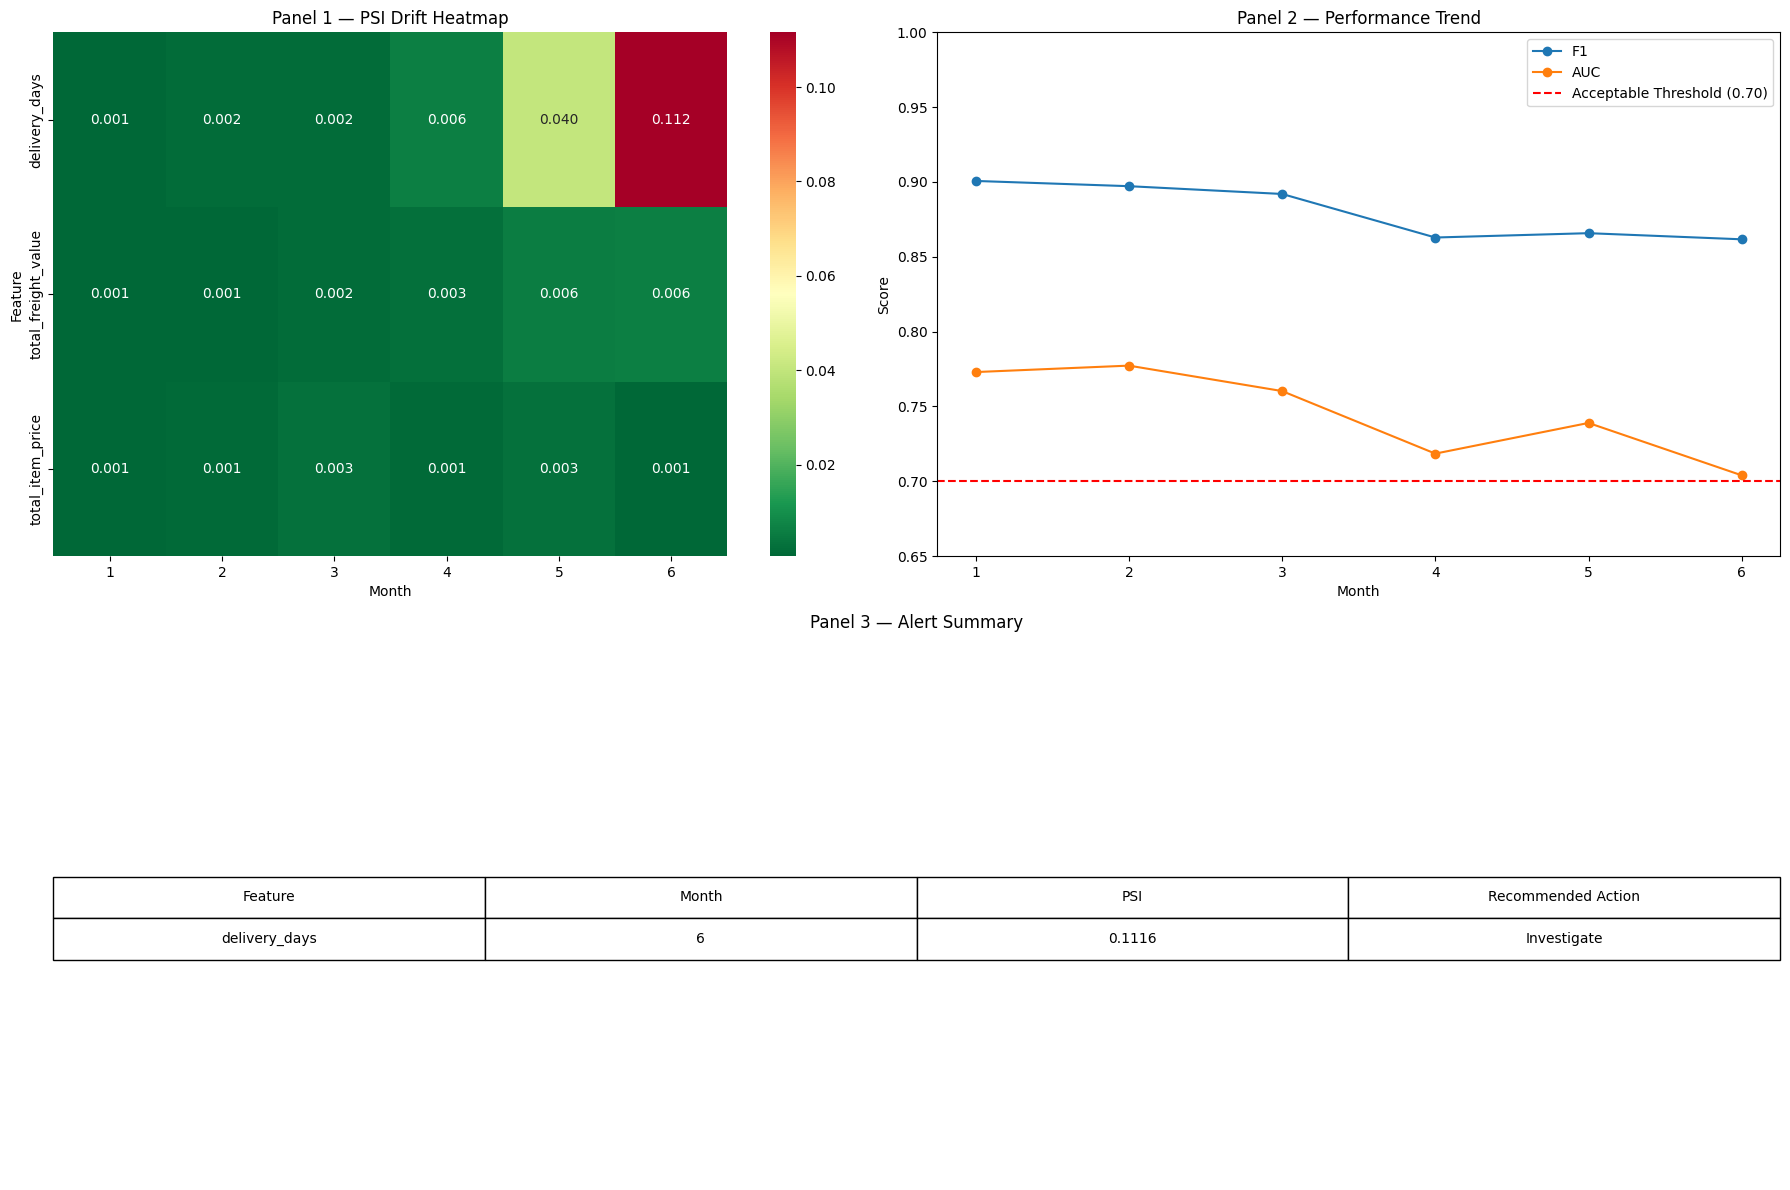

In [184]:
# create single 3-panel monitoring figure
fig = plt.figure(figsize=(18, 12))

# -------- Panel 1: Drift Heatmap --------
ax1 = plt.subplot2grid((2, 2), (0, 0))
sns.heatmap(
    psi_heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    cbar=True,
    ax=ax1
)
ax1.set_title("Panel 1 — PSI Drift Heatmap")
ax1.set_xlabel("Month")
ax1.set_ylabel("Feature")

# -------- Panel 2: Performance Trend --------
ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(monthly_metrics_df["month"], monthly_metrics_df["f1"], marker="o", label="F1")
ax2.plot(monthly_metrics_df["month"], monthly_metrics_df["auc"], marker="o", label="AUC")
ax2.axhline(y=0.70, linestyle="--", color="red", label="Acceptable Threshold (0.70)")
ax2.set_title("Panel 2 — Performance Trend")
ax2.set_xlabel("Month")
ax2.set_ylabel("Score")
ax2.set_xticks(monthly_metrics_df["month"])
ax2.set_ylim(0.65, 1.0)
ax2.legend()

# -------- Panel 3: Alert Summary Table --------
ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.axis("off")
ax3.set_title("Panel 3 — Alert Summary", pad=20)

table = ax3.table(
    cellText=alerts_df.values,
    colLabels=alerts_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

plt.tight_layout()
plt.show()

Part 5e:

Yes, the model should be retrained eventually. In my case, month 6 is the clear trigger point because by then delivery_days was at a PSI of .1116, which is in the moderate drift range. The slow deterioration over time should be closesly monitored to avoid going past these levels. From months 1-6 accuracy dropped by about 7%, F1 by 4% and AUC by about 9%. While still usable, it is clearly declining and becoming less reliable as conditions shift from the original training environment. I would retrain when PSI goes above .10 for the operationally important features. It shold include the most recent production data available, even better if from the drifting months.